<a href="https://colab.research.google.com/github/MDankloff/ClusterCompasCredit/blob/main/K-Prototypes/01_2026_german_credit_Kprototypes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [1]:
!pip install kmodes

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import random
import os
import math
import scipy.stats as stats
from scipy.stats import chi2_contingency
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_samples, silhouette_score
from scipy import stats
from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from google.colab import files
import re
from kmodes.kprototypes import KPrototypes, k_prototypes
from kmodes.util.dissim import matching_dissim
from kmodes.kmodes import KModes

import warnings
warnings.filterwarnings('ignore')

# UTILS

## Sets of Features (aka data columns)

In [3]:
#Master Dataset
#FEATURES
META = ['clusters', 'new_clusters', 'Error_Type']
ERROR = ['errors', 'TP', 'TN', 'FN', 'FP']
REG = ['Age', 'Single', 'Unemployed', 'LoanAmount']
DUMMY = ['Gender_F', 'OwnsHouse', 'ForeignWorker'] #sensitive / protected attributes

#FEATURES SCALED
ERROR_scaled = ['errors_scaled']
REG_scaled = ['Age_scaled','Single_scaled', 'Unemployed_scaled',
               'LoanAmount_scaled']
DUMMY_scaled = ['Gender_F_scaled', 'OwnsHouse_scaled','ForeignWorker_scaled']

#SHAP is created on REG_scaled and DUMMY_scaled
SHAP_REG = ['Shap_Age','Shap_Single','Shap_Unemployed', 'Shap_LoanAmount']
SHAP_DUMMY = ['Shap_Gender_F', 'Shap_OwnsHouse','Shap_ForeignWorker']

#SHAP FEATURES SCALED
SHAP_REG_scaled = ['Shap_Age_scaled', 'Shap_Single_scaled', 'Shap_Unemployed_scaled',
                   'Shap_LoanAmount_scaled']
SHAP_DUMMY_scaled = ['Shap_Gender_F_scaled', 'Shap_OwnsHouse_scaled', 'Shap_ForeignWorker_scaled']

## Utils for Data Prep

In [4]:
#Separate TPFN & TNFP dataset
'''Drop rows where both TP and FN are 0 '''
def subset_TP_FN(data):
    return data.loc[(data['TP'] == 1) | (data['FN'] == 1)]

'''Drop rows where both TN and FP are 0'''
def subset_TN_FP(data):
    return data.loc[(data['TN'] == 1) | (data['FP'] == 1)]

## Utils for Clustering

In [5]:
def get_error_rate(data, column='errors'):
  if len(data) == 0:
    print ('calculating error rate on an empty set')
    return
  max_value = data[column].astype(int).max()
  count_max_value = (data[column].astype(int) == max_value).sum()
  average_error_rate = count_max_value / len(data)
  return average_error_rate

In [6]:
def get_next_cluster(data, cluster_col, min_size, all_cluster_ids, banned_clusters):
  if(len(banned_clusters) != 0):
    filter_tf = np.isin(all_cluster_ids, banned_clusters, invert=True)
    all_cluster_ids = all_cluster_ids[filter_tf]

  for candidate_cluster_id in all_cluster_ids:
    if candidate_cluster_id == -1:
      continue

    #print ('This is the next cluster:', candidate_cluster_id)

    candidate_cluster = data.loc[data[cluster_col] == candidate_cluster_id]

    if len(candidate_cluster) < min_size:
      #print('...it is too small:', len(candidate_cluster))
      continue
    else:
      return(candidate_cluster_id)

  #print('No suitable clusters were found!')
  return(-1)

## Utils for Results

### Recap

In [10]:
def make_recap(data_result, feature_set):
  # MAKE RECAP of cluster info
  # ...with error rates
  res = data_result[['clusters', 'errors']]

  # ...with cluster size
  temp = data_result[['clusters']]
  temp['count'] = 1
  recap = temp.groupby(['clusters'], as_index=False).sum()

  # ...with number of error
  recap['n_error'] = res.groupby(['clusters']).sum().astype(int)

  # ...with 1-vs-All error diff
  recap['error_rate'] = res.groupby(['clusters']).mean()
  # recap['std'] = (recap['error_rate'] * (1-recap['error_rate']))/recap['count']
  # recap['std'] = recap['std'].apply(np.sqrt)

  # Prepare Quality metrics
  diff_vs_rest = []
  # diff_std = []
  diff_p =[]

  foreign_prop = []
  foreign_diff = []
  foreign_p = []

  houseowner_prop = []
  houseowner_diff = []
  houseowner_p = []

  female_prop = []
  female_diff = []
  female_p = []

  silhouette = []

  # Get individual silhouette scores
  clusters = data_result['clusters']
  if(len(recap['clusters'].unique()) > 1):
    silhouette_val = silhouette_samples(data_result[feature_set], clusters)

  for c in recap['clusters']:
    # Get in-cluster data
    c_data = data_result.loc[data_result['clusters'] == c]
    c_count = recap['count'][c]

    # Get out-of-cluster data
    rest_data = data_result.loc[data_result['clusters'] != c]
    # Check if no other cluster
    if(len(rest_data) == 0):
      diff_vs_rest.append(np.nan)
      # diff_std.append(np.nan)
      diff_p.append(np.nan)

      foreign_prop.append(np.nan)
      foreign_diff.append(np.nan)
      foreign_p.append(np.nan)

      houseowner_prop.append(np.nan)
      houseowner_diff.append(np.nan)
      houseowner_p.append(np.nan)

      female_prop.append(np.nan)
      female_diff.append(np.nan)
      female_p.append(np.nan)

      silhouette.append(np.nan)
      break

    # Add silhouette score
    silhouette.append(silhouette_val[clusters == c].mean())

    rest_recap = recap.loc[recap['clusters'] != c]
    rest_count = rest_recap['count'].sum()

    #### Quick test: differences in error rates
    # Get error rate difference 1-vs-rest
    rest_n_error = rest_recap['n_error'].sum()
    rest_rate = rest_n_error / rest_count
    diff_vs_rest.append(recap['error_rate'][c] - rest_rate)

    # ...with std deviation of error differences
    # std_rest = (rest_rate * (1-rest_rate))/rest_count
    # std_rest = np.sqrt(std_rest)
    # diff_std.append(recap['std'][c] + std_rest)

    # ...with Poisson stat testprint('Zero!')
    # Deal with splits with 0 error (by using either number of errors (FN or FP), or number of correct classifications (TP or TN))
    if((recap['n_error'][c] < 1) | (recap['count'][c] < 1) | (rest_n_error < 1) | (rest_count < 1)):
      res = stats.poisson_means_test(recap['count'][c] - recap['n_error'][c], recap['count'][c], rest_count - rest_n_error, rest_count)
      diff_p.append(round(res.pvalue, 3))
    else:
      res = stats.poisson_means_test(recap['n_error'][c], recap['count'][c], rest_n_error, rest_count)
      diff_p.append(round(res.pvalue, 3))

    ##### Sensitive features (GENDER, FOREIGN WORKER, HOUSE OWNER) -- ['Gender_F_scaled', 'ForeignWorker_scaled', ''OwnsHouse_scaled'' ]
    ### ForeignWorker
    rest_n_ForeignWorker = rest_data['ForeignWorker'].sum()
    rest_prop_ForeignWorker = rest_n_ForeignWorker / rest_count

    c_n_ForeignWorker = c_data['ForeignWorker'].sum()
    c_prop_ForeignWorker = c_n_ForeignWorker / c_count

    foreign_prop.append(c_prop_ForeignWorker)
    foreign_diff.append(c_prop_ForeignWorker - rest_prop_ForeignWorker)

    # Deal with splits with 0 foreign workers (by using either number of foreign workers, or number of non- foreign workers)
    if((c_n_ForeignWorker < 1) | (c_count < 1) | (rest_n_ForeignWorker < 1) | (rest_count < 1)):
      res = stats.poisson_means_test(c_count - c_n_ForeignWorker, c_count, rest_count - rest_n_ForeignWorker, rest_count)
      foreign_p.append(round(res.pvalue, 3))
    else:
      res = stats.poisson_means_test(c_n_ForeignWorker, c_count, rest_n_ForeignWorker, rest_count)
      foreign_p.append(round(res.pvalue, 3))

    ### House owner
    rest_n_houseowner = rest_data['OwnsHouse'].sum()
    rest_prop_houseowner = rest_n_houseowner / rest_count

    c_n_houseowner = c_data['OwnsHouse'].sum()
    c_prop_houseowner = c_n_houseowner / c_count

    houseowner_prop.append(c_prop_houseowner)
    houseowner_diff.append(c_prop_houseowner - rest_prop_houseowner)

    # Deal with splits with 0 House Owners (by using either number of House Ownser, or number of non-House owners)
    if((c_n_houseowner < 1) | (c_count < 1) | (rest_n_houseowner < 1) | (rest_count < 1)):
      res = stats.poisson_means_test(c_count - c_n_houseowner, c_count, rest_count - rest_n_houseowner, rest_count)
      houseowner_p.append(round(res.pvalue, 3))
    else:
      res = stats.poisson_means_test(c_n_houseowner, c_count, rest_n_houseowner, rest_count)
      houseowner_p.append(round(res.pvalue, 3))

    ##### Gender
    rest_n_female = rest_data['Gender_F'].sum()
    rest_prop_female = rest_n_female/ rest_count

    c_n_female = c_data['Gender_F'].sum()
    c_prop_female = c_n_female / c_count

    female_prop.append(c_prop_female)
    female_diff.append(c_prop_female - rest_prop_female)

    # Deal with splits with 0 females(by using either number of females, or number of males)
    if((c_n_female < 1) | (c_count < 1) | (rest_n_female < 1) | (rest_count < 1)):
      res = stats.poisson_means_test(c_count - c_n_female, c_count, rest_count - rest_n_female, rest_count)
      female_p.append(round(res.pvalue, 3))
    else:
      res = stats.poisson_means_test(c_n_female, c_count, rest_n_female, rest_count)
      female_p.append(round(res.pvalue, 3))

  recap['diff_vs_rest'] = np.around(diff_vs_rest, 3)
  # recap['diff_std'] = np.around(diff_std, 3)
  recap['diff_p'] = diff_p

  recap['foreign_prop'] = np.around(foreign_prop, 3)
  recap['foreign_diff'] = np.around(foreign_diff, 3)
  recap['foreign_p'] = foreign_p

  recap['houseowner_prop'] = np.around(houseowner_prop, 3)
  recap['houseowner_diff'] = np.around(houseowner_diff, 3)
  recap['houseowner_p'] = houseowner_p

  recap['female_prop'] = np.around(female_prop, 3)
  recap['female_diff'] = np.around(female_diff, 3)
  recap['female_p'] = female_p

  recap['silhouette'] = silhouette

  recap['error_rate'] = np.around(recap['error_rate'] , 3)
  # recap['std'] = np.around(recap['std'] , 3)

  recap.rename(columns={'clusters':'c'}, inplace=True)
  #print(recap.sort_values(by=['diff_p']))

  return(recap)

### Chi-Square Tests

In [11]:
def make_chi_tests(results):
  chi_res = {'cond_descr': [],
            'cond_name': [],
            'error': [],
            'foreign': [],
            'house': [],
            'gender': []}

  for i in range(0, len(results['cond_name'])):
    chi_res['cond_descr'].append(results['cond_descr'][i])
    chi_res['cond_name'].append(results['cond_name'][i])
    data = results['cond_res'][i]
    recap = results['cond_recap'][i]

    if(len(recap['diff_p']) == 1):
      chi_res['error'].append(np.nan)
      chi_res['foreign'].append(np.nan)
      chi_res['house'].append(np.nan)
      chi_res['gender'].append(np.nan)
      continue

    # Test error differences
    test_data = recap[['count', 'n_error']].copy(deep=True)

    test_data['count'] = test_data['count'] - test_data['n_error']
    test_data = test_data.rename(columns={"count": "n_correct"})

    test_data = test_data.transpose()
    test_res = chi2_contingency(test_data)
    chi_res['error'].append(round(test_res.pvalue, 6))

    #print(test_data)
    # print(round(test_res.pvalue, 6))

    # Test gender differences
    test_data = recap[['count', 'female_prop']].copy(deep=True)

    test_data['female_prop'] = round(test_data['count'] * test_data['female_prop'])
    test_data = test_data.rename(columns={"female_prop": "female_n"}).astype(int)

    test_data['count'] = test_data['count'] - test_data['female_n']
    test_data = test_data.rename(columns={"count": "male_n"})

    test_data = test_data.transpose()
    test_res = chi2_contingency(test_data)
    chi_res['gender'].append(round(test_res.pvalue, 6))

    # print(test_data)
    # print(round(test_res.pvalue, 6))

    # Test Foreign worker differences
    test_data = recap[['count', 'foreign_prop']].copy(deep=True)

    test_data['foreign_prop'] = round(test_data['count'] * test_data['foreign_prop'])
    test_data = test_data.rename(columns={"foreign_prop": "foreign_n"}).astype(int)

    test_data['count'] = test_data['count'] - test_data['foreign_n']
    test_data = test_data.rename(columns={"count": "not_foreign_n"})

    test_data = test_data.transpose()
    test_res = chi2_contingency(test_data)
    chi_res['foreign'].append(round(test_res.pvalue, 6))

    # print(test_data)
    # print(round(test_res.pvalue, 6))

    # Test House owner differences
    test_data = recap[['count', 'houseowner_prop']].copy(deep=True)

    test_data['houseowner_prop'] = round(test_data['count'] * test_data['houseowner_prop'])
    test_data = test_data.rename(columns={"houseowner_prop": "houseowner_n"}).astype(int)

    test_data['count'] = test_data['count'] - test_data['houseowner_n']
    test_data = test_data.rename(columns={"count": "not_houseowner_n"})

    test_data = test_data.transpose()
    test_res = chi2_contingency(test_data)
    chi_res['house'].append(test_res.pvalue)

    # print(test_data)
    # print(round(test_res.pvalue, 6))'''

  return(pd.DataFrame(chi_res))

### All Quality Metrics

In [12]:
def recap_quali_metrics(chi_res, results, exp_condition):
  all_quali = {'cond_descr': chi_res['cond_descr'],
            'cond_name': chi_res['cond_name'],
            'error': chi_res['error'],
            'foreign': chi_res['foreign'],
            'house': chi_res['house'],
            'gender': chi_res['gender'],
            'silhouette': []}

  for i in range(0, len(chi_res['cond_name'])):
    data = results['cond_res'][i]
    feature_set = exp_condition['feature_set'][i]
    clusters = data['clusters']
    recap = results['cond_recap'][i]
    if(len(recap['diff_p']) == 1):
      all_quali['silhouette'].append(np.nan)
      continue
    silhouette_indiv = silhouette_samples(data[feature_set], clusters)
    silhouette_avg = silhouette_indiv.mean()
    all_quali['silhouette'].append(silhouette_avg)

  return(pd.DataFrame(all_quali))

## UTILS for Viz

In [13]:
def tsne_plot_wClusters(data, title, perplexity, learning_rate, n_iter, alpha, size, tsne_columns, fig_prefix):
  # Extract features for t-SNE and drop other_columns
  tsne_features = data[tsne_columns]
  other_columns = [col for col in data.columns if col not in tsne_features]
  other_features = data[other_columns]

  tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=learning_rate, n_iter=n_iter)
  tsne_result = tsne.fit_transform(tsne_features)
  tsne_df = pd.DataFrame(tsne_result, index = tsne_features.index, columns=['t-SNE Component 1', 't-SNE Component 2'])

  temp_dataset = tsne_df.join(other_features, how='left')

  # Create scatterplot using seaborn
  scatterplot = sns.scatterplot(data=temp_dataset, x='t-SNE Component 1', y='t-SNE Component 2', alpha=alpha, s=size,
                                hue="clusters", palette='tab10', style='Error_Type')
  scatterplot.set_title(title)
  scatterplot.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), ncol=1)

  plt.savefig(fig_prefix+re.sub(' +', '', title)+'.png', bbox_inches='tight', pad_inches=0)
  plt.show()

# K-PROTOTYPES CLUSTERING

In [20]:
def hbac_proto(data, columns_to_use=[], error='errors',
                exp_condition_name = '',
                min_splittable_cluster_prop = 0.01,
                min_acceptable_cluster_prop = 0.03,
                min_acceptable_error_diff = 0.005,
                max_iter=300,
                init = 'random',
               random_state =None):
    clus_model_kwargs = {
        "n_clusters": 2,  # Number of clusters to form
        "init": "k-means++",  # Centroids initialization method
        "n_init": 10,  # Number of initializations
        "max_iter": max_iter  # Maximum iterations for a single run
    }
    #print(exp_condition_name)

    min_splittable_cluster_size = round(min_splittable_cluster_prop * len(data))  # Minimum size of cluster to be split
    min_acceptable_cluster_size = round(min_acceptable_cluster_prop * len(data))  # Minimum acceptable size of cluster after split

    # Initialize loop's variables
    data['clusters'] = 0
    banned_clusters = []
    labels = []

    #### CLUSTERING LOOP
    for i in range(1, max_iter):
      # Init temporary cluster
      data['new_clusters'] = None

      ### Select the cluster to split in 2
      x = get_next_cluster(data, 'clusters', min_splittable_cluster_size, data['clusters'].unique(), banned_clusters)
      if(x == -1):
        break

      candidate_cluster = data.copy(deep=True)
      candidate_cluster = candidate_cluster.loc[candidate_cluster['clusters'] == x]

      #### SPLIT IN 2 SUB-CLUSTERS
          # Check if all features are numerical
      if all(candidate_cluster[columns_to_use].dtypes != 'category') and not (exp_condition_name == '-reg +SEN +ERR -shap' or exp_condition_name == '-reg +SEN -err -shap'):
        # Use k-means for numerical-only features
        kmeans = KMeans(**clus_model_kwargs, random_state=random_state).fit(candidate_cluster[columns_to_use])
        labels = kmeans.labels_
      elif exp_condition_name == '-reg +SEN +ERR -shap' or exp_condition_name == '-reg +SEN -err -shap':
        # Convert boolean columns to object for KModes
        candidate_cluster[columns_to_use] = candidate_cluster[columns_to_use].astype(object)

        # Use k-modes for categorical-only features (including converted booleans)
        np.random.seed(random_state)
        model = KModes(n_clusters=2, init=init, n_init=10, verbose=0, random_state = random_state)
        labels = model.fit_predict(candidate_cluster[columns_to_use])
      else:
        # Use k-prototypes for mixed features
        model = KPrototypes(n_clusters=2, init=init, n_init=10, verbose=0, random_state=random_state)
        categorical_indices = [i for i, col in enumerate(columns_to_use) if candidate_cluster[col].dtype == 'category']
        labels = model.fit_predict(candidate_cluster[columns_to_use], categorical=categorical_indices)

      candidate_cluster['new_clusters'] = labels

      # KEEP CLUSTER OR NOT
      # ...are cluster size large enough?
      l0 = len(candidate_cluster.loc[candidate_cluster['new_clusters'] == 0])
      l1 = len(candidate_cluster.loc[candidate_cluster['new_clusters'] == 1])

      if((l0 < min_acceptable_cluster_size) | (l1 < min_acceptable_cluster_size)):
        #print('Bad split: too small')
        banned_clusters.append(x)
        continue

      # ...is error rate difference large enough?
      e0 = get_error_rate(candidate_cluster.loc[candidate_cluster['new_clusters'] == 0])
      e1 = get_error_rate(candidate_cluster.loc[candidate_cluster['new_clusters'] == 1])

      if(abs(e0 - e1) < min_acceptable_error_diff):
        #print('Bad split: same error')
        banned_clusters.append(x)
        continue

      ### Re-integrate to main data
      data['new_clusters'] = candidate_cluster['new_clusters'].combine_first(data['new_clusters'])

      # Make new Cluster IDs
      new_id = data['clusters'].unique().max() + 1
      data.loc[((data.clusters == x) & (data.new_clusters == 1)), 'clusters'] = new_id

    #print('Max iterations reached:', i)
    return data

# SETUP EXPERIMENTS

### Prepare Data

In [15]:
credit = pd.read_csv('https://raw.githubusercontent.com/MDankloff/ClusterCompas/main/Data/credit_all.csv')

In [16]:
#split into TP/FN and TN/FP
TPFN_data = subset_TP_FN(credit)
TNFP_data = subset_TN_FP(credit)

# Drop NA's
TPFN_data = TPFN_data.dropna()
TNFP_data = TNFP_data.dropna()

In [17]:
#TPFN_data.info()

### Set experimental conditions

In [18]:
##### Make and name the sets of features to experiment with
feature_set_name = []
feature_set_descr = []
feature_set = []


############ SHAP-ONLY HBAC
### Does SHAP alone allow to identify clusters?
# Using only SHAP values
feature_set_name.append('SHAP')
feature_set_descr.append('SHAP only')
feature_set.append(SHAP_REG_scaled + SHAP_DUMMY_scaled)

'''# Using only SHAP of Regular features
feature_set_name.append('SHAP_R')
feature_set_descr.append('Only SHAP of Regular features')
feature_set.append(SHAP_REG_scaled)

# Using only SHAP of Sensitive features
feature_set_name.append('SHAP_S')
feature_set_descr.append('Only SHAP of Sensitive features')
feature_set.append(SHAP_DUMMY_scaled)'''

################################# Error and SHAP
feature_set_name.append('SHAP +ERR')
feature_set_descr.append('SHAP only with Error')
feature_set.append(SHAP_REG_scaled + SHAP_DUMMY_scaled + ERROR_scaled)

'''feature_set_name.append('SHAP_S +ERR')
feature_set_descr.append('Only SHAP of Sensitive features')
feature_set.append(SHAP_DUMMY_scaled + ERROR_scaled)

feature_set_name.append('SHAP_R +ERR')
feature_set_descr.append('Only SHAP of Regular features + Error')
feature_set.append(SHAP_REG_scaled + ERROR_scaled)'''


################### REG
feature_set_name.append('REG')
feature_set_descr.append('REG Only')
feature_set.append(REG_scaled)

'''feature_set_name.append('REG +SHAP')
feature_set_descr.append('REG & SHAP')
feature_set.append(SHAP_REG_scaled + REG_scaled) # ERROR FIXED'''

feature_set_name.append('REG +SHAP_R')
feature_set_descr.append('REG & SHAP')
feature_set.append(SHAP_REG_scaled + REG_scaled)

feature_set_name.append(f'REG +SEN')
feature_set_descr.append('Baseline')
feature_set.append(REG_scaled + DUMMY_scaled)

feature_set_name.append(f'REG +SEN +SHAP')
feature_set_descr.append('Baseline with SHAP')
feature_set.append(REG_scaled + DUMMY_scaled + SHAP_REG_scaled + SHAP_DUMMY_scaled)

feature_set_name.append('REG +ERR')
feature_set_descr.append('REG & ERROR')
feature_set.append(REG_scaled + ERROR_scaled)

feature_set_name.append('REG +ERR +SHAP_R')
feature_set_descr.append('REG, ERROR & SHAP')
feature_set.append(SHAP_REG_scaled + REG_scaled + ERROR_scaled) # ERROR FIXED

feature_set_name.append('REG +SEN +ERR')
feature_set_descr.append('Baseline with Error')
feature_set.append(REG_scaled + DUMMY_scaled + ERROR_scaled)

feature_set_name.append('REG +SEN +ERR +SHAP')
feature_set_descr.append('Baseline with SHAP & Error')
feature_set.append(REG_scaled + DUMMY_scaled + SHAP_REG_scaled + SHAP_DUMMY_scaled + ERROR_scaled)


############ ONLY SENSITIVE FEATURES
### Do sensitive features alone allow to identify clusters?
# Using only Sensitive features
feature_set_name.append('SEN')
feature_set_descr.append('Sensitive features only')
feature_set.append(DUMMY_scaled)

### Does adding SHAP help the clustering based on sensitive features?
# Using Sensitive features with SHAP values
feature_set_name.append('SEN +SHAP_S')
feature_set_descr.append('Sensitive features with SHAP')
feature_set.append(DUMMY_scaled + SHAP_DUMMY_scaled)

feature_set_name.append('SEN +ERR')
feature_set_descr.append('Sensitive features with Error')
feature_set.append(DUMMY_scaled + ERROR_scaled)

feature_set_name.append('SEN +ERR +SHAP_S')
feature_set_descr.append('Sensitive features with SHAP & Error')
feature_set.append(DUMMY_scaled + SHAP_DUMMY_scaled + ERROR_scaled)


exp_condition = pd.DataFrame({'feature_set_descr': feature_set_descr,
                              'feature_set_name': feature_set_name,
                              'feature_set': feature_set})
exp_condition

,feature_set_descr,feature_set_name,feature_set
0,SHAP only,SHAP,"[Shap_Age_scaled, Shap_Single_scaled, Shap_Une..."
1,SHAP only with Error,SHAP +ERR,"[Shap_Age_scaled, Shap_Single_scaled, Shap_Une..."
2,REG Only,REG,"[Age_scaled, Single_scaled, Unemployed_scaled,..."
3,REG & SHAP,REG +SHAP_R,"[Shap_Age_scaled, Shap_Single_scaled, Shap_Une..."
4,Baseline,REG +SEN,"[Age_scaled, Single_scaled, Unemployed_scaled,..."
5,Baseline with SHAP,REG +SEN +SHAP,"[Age_scaled, Single_scaled, Unemployed_scaled,..."
6,REG & ERROR,REG +ERR,"[Age_scaled, Single_scaled, Unemployed_scaled,..."
7,"REG, ERROR & SHAP",REG +ERR +SHAP_R,"[Shap_Age_scaled, Shap_Single_scaled, Shap_Une..."
8,Baseline with Error,REG +SEN +ERR,"[Age_scaled, Single_scaled, Unemployed_scaled,..."
9,Baseline with SHAP & Error,REG +SEN +ERR +SHAP,"[Age_scaled, Single_scaled, Unemployed_scaled,..."


# TNFP RESULTS


### Execute experiments

In [21]:
#hbac parameters
min_splittable_cluster_prop = 0.01
min_acceptable_cluster_prop = 0.03
min_acceptable_error_diff = 0.005

seeds = list(range(10))
all_results = []


#from ctypes import Array
for seed in seeds:
  np.random.seed(seed)
  random.seed(seed)

  results_for_seed = {'cond_name': [],
          'cond_descr': [],
          'cond_res': [],
          'cond_recap': []}

  for i in range(len(exp_condition)):
    res = hbac_proto(TNFP_data.copy(deep=True),
                     columns_to_use = exp_condition['feature_set'][i],
                     exp_condition_name = re.sub(' +', ' ', exp_condition['feature_set_name'][i]),
                     error='errors',
                     min_splittable_cluster_prop = min_splittable_cluster_prop,
                     min_acceptable_cluster_prop = min_acceptable_cluster_prop,
                     min_acceptable_error_diff = min_acceptable_error_diff,
                     max_iter=100,
                     random_state = seed
                     )

    recap = make_recap(res, exp_condition['feature_set'][i])

    results_for_seed['cond_name'].append(exp_condition['feature_set_name'][i])
    results_for_seed['cond_descr'].append(exp_condition['feature_set_descr'][i])
    results_for_seed['cond_res'].append(res)
    results_for_seed['cond_recap'].append(recap)

  all_results.append(results_for_seed)

results = all_results[0]

### Chi-Square Tests TNFP data

In [23]:
chi_dfs = []
quali_dfs = []

for seed_results in all_results:
  chi_df = make_chi_tests(seed_results)
  quali_df = recap_quali_metrics(chi_df, seed_results, exp_condition)

  chi_dfs.append(chi_df)
  quali_dfs.append(quali_df)

chi_all = pd.concat(chi_dfs, ignore_index=True)
quali_all = pd.concat(quali_dfs, ignore_index=True)

chi_summary = chi_all.groupby("cond_name")[['error', 'foreign', 'house', 'gender']].agg(["mean", "std"])
quali_summary = quali_all.groupby("cond_name")[['error', 'foreign', 'house', 'gender', 'silhouette']].agg(["mean", "std"])

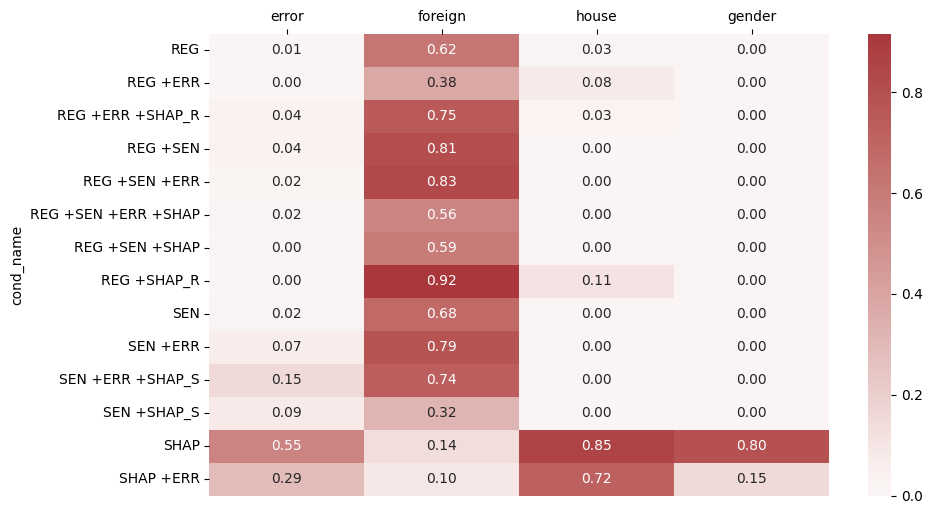

In [24]:
chi_mean = chi_summary.xs('mean', axis=1, level=1)

plt.figure(figsize=(10,6))
ax = sns.heatmap(
    chi_mean,
    annot=True,        # mean values
    fmt='.2f',         # 2 decimals
    center=0,
    cmap=sns.color_palette("vlag", as_cmap=True),
    robust=False
)
ax.xaxis.tick_top()
plt.yticks(rotation='horizontal')
plt.show()

### All Quality Metrics TNFP data

In [25]:
quali_mean_values = quali_summary.xs('mean', axis=1, level=1)
#quali_std_values = quali_summary.xs('std', axis=1, level=1)

# Create a DataFrame for annotations (mean only)
quali_annot_df = pd.DataFrame(index=quali_mean_values.index, columns=quali_mean_values.columns)

for col in quali_mean_values.columns:
    quali_annot_df[col] = [f"{m:.2f}" for m in quali_mean_values[col]]

all_quali_viz = quali_mean_values

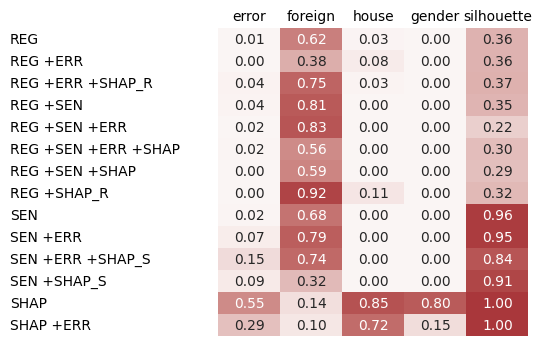

In [26]:
plt.figure(figsize=(4,4))
ax = sns.heatmap(all_quali_viz, annot=quali_annot_df, fmt='', center=0, cbar=False,
                cmap=sns.color_palette("vlag", as_cmap=True), robust=True)
ax.set(xlabel="", ylabel="")
ax.xaxis.tick_top()
ax.tick_params(axis='x', which='major', length=0)
ax.tick_params(axis='y', which='major', pad=150, length=0)
plt.yticks(ha='left')
plt.savefig('TNFP_Kproto.png', bbox_inches='tight', pad_inches=0)
#files.download('TNFP_Kproto.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

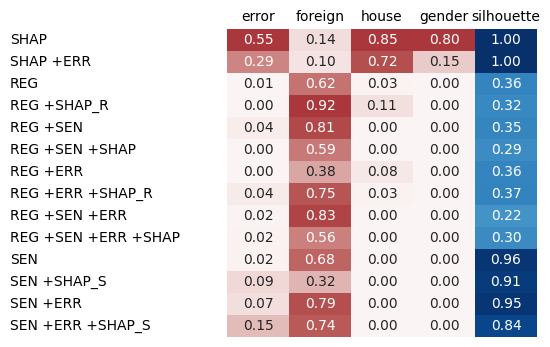

In [27]:

fig, axes = plt.subplots(1, len(all_quali_viz.columns), figsize=(4, 4), sharey=True)

colormap_dict = {
    'error': 'vlag',
    'foreign': 'vlag',
    'house': 'vlag',
    'gender': 'vlag',
    'silhouette': 'Blues'
}

# Reindex all_quali_viz and quali_annot_df to match the order in exp_condition
ordered_cond_names = exp_condition['feature_set_name'].tolist()
all_quali_viz_ordered = all_quali_viz.reindex(ordered_cond_names)
quali_annot_df_ordered = quali_annot_df.reindex(ordered_cond_names)

# Iterate through columns and apply colormaps individually
for i, column in enumerate(all_quali_viz_ordered.columns):
    sns.heatmap(
        all_quali_viz_ordered[[column]],  # Select a single column for each iteration
        annot=quali_annot_df_ordered[[column]], # Use the formatted annotations
        fmt='',                    # No default formatting needed as annot is already formatted
        center=0,
        cmap=colormap_dict[column],  # Use the appropriate colormap from the dictionary
        robust=True,
        cbar=False,
        ax=axes[i],  # Use the corresponding subplot
        xticklabels=False,
        #annot_kws={"size": 8}
    )

    axes[i].set_title(column, size = 10)  # Set title for each subplot
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")  # Remove y-axis label (cond_name)
    axes[i].set_yticks([])

    # Add condition names as text labels on the left
    if i == 0: # Only add labels to the first subplot
        for j, cond_name in enumerate(all_quali_viz_ordered.index):
            axes[i].text(-3.5, j + 0.5, cond_name, ha='left', va='center')


plt.subplots_adjust(wspace=0)

# Save the figure
plt.savefig("TNFP_KPrototypes_credit_new.png", bbox_inches="tight", pad_inches=0)
files.download('TNFP_KPrototypes_credit_new.png')
# Show the plot
plt.show()

# DETAILED TNFP RESULTS

## One-vs-All cluster comparison TNFP data

0


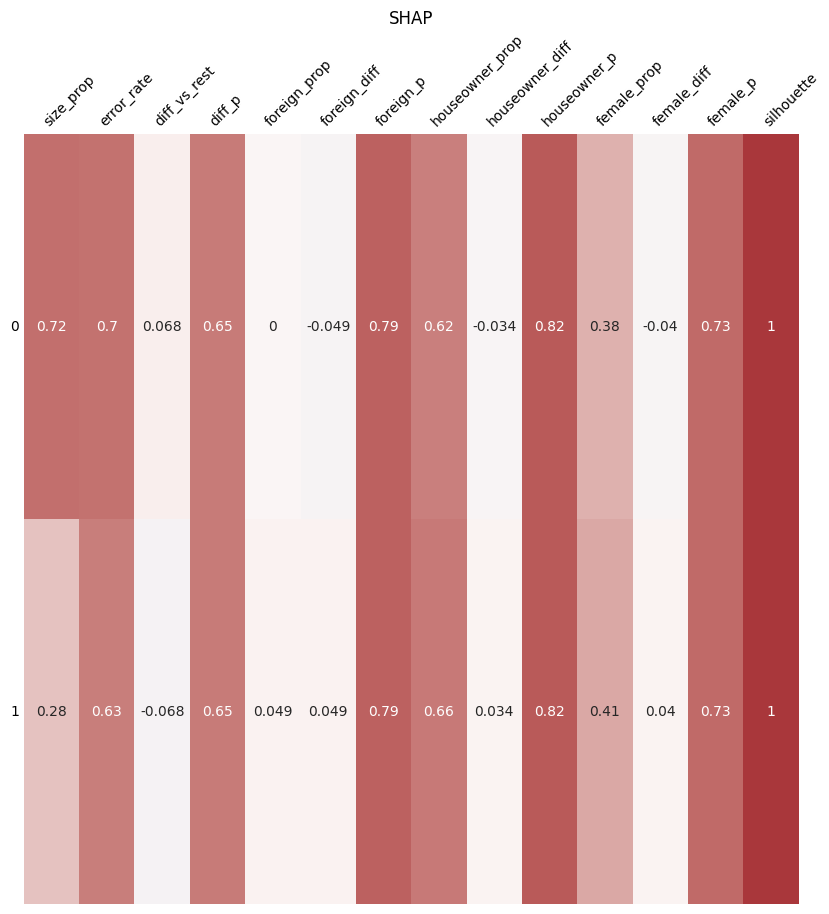

1


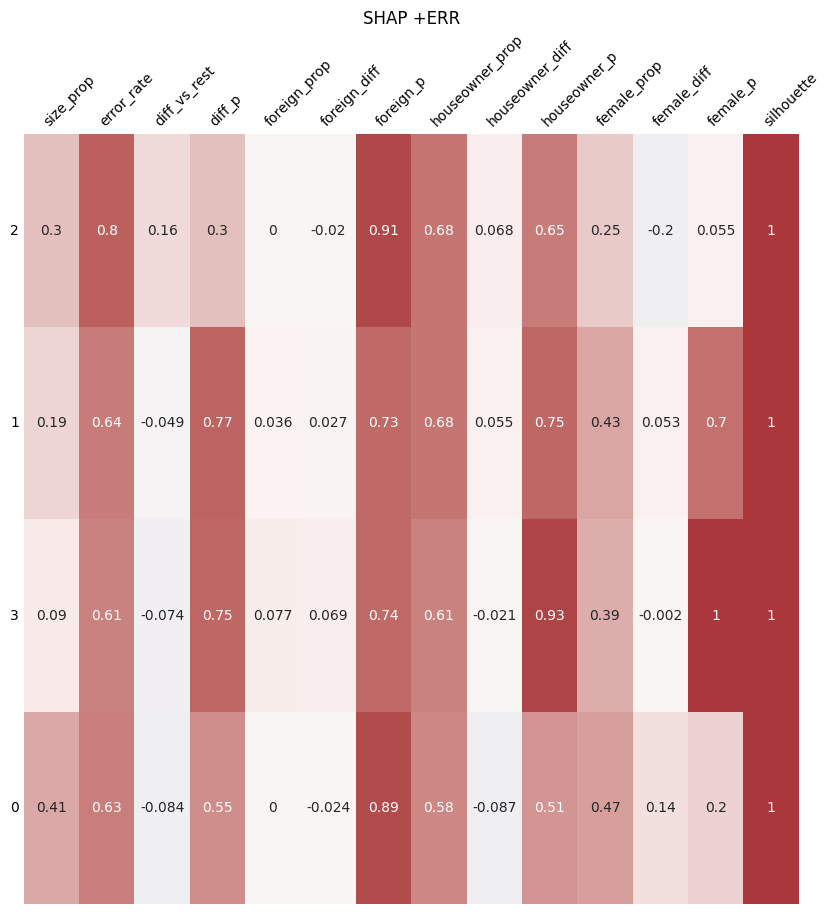

2


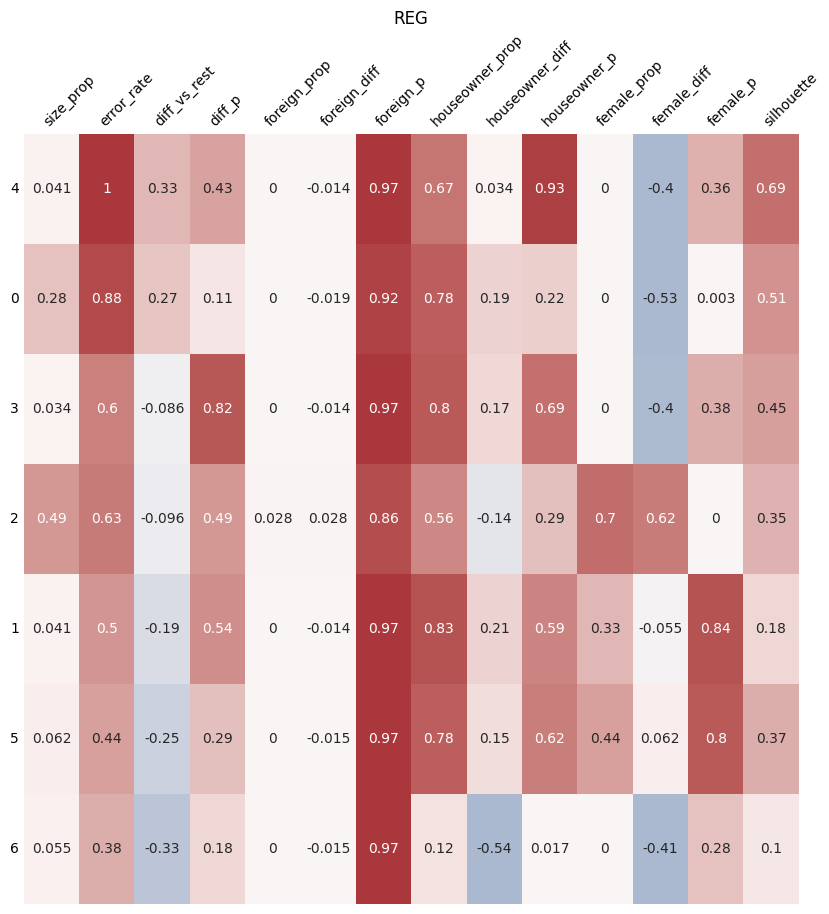

3


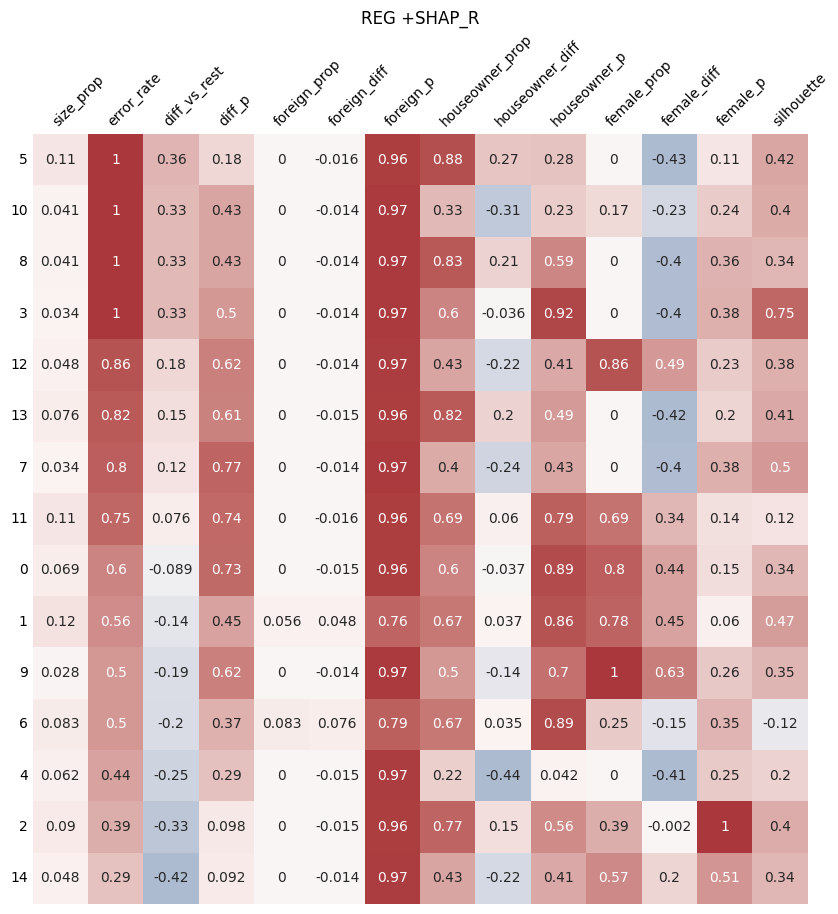

4


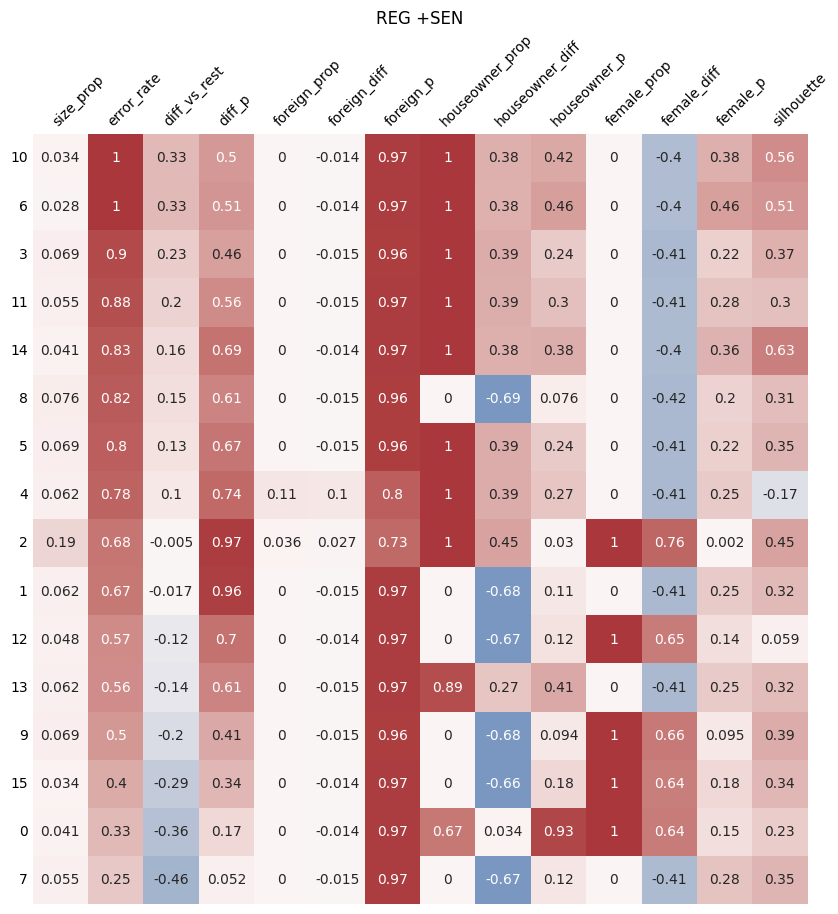

5


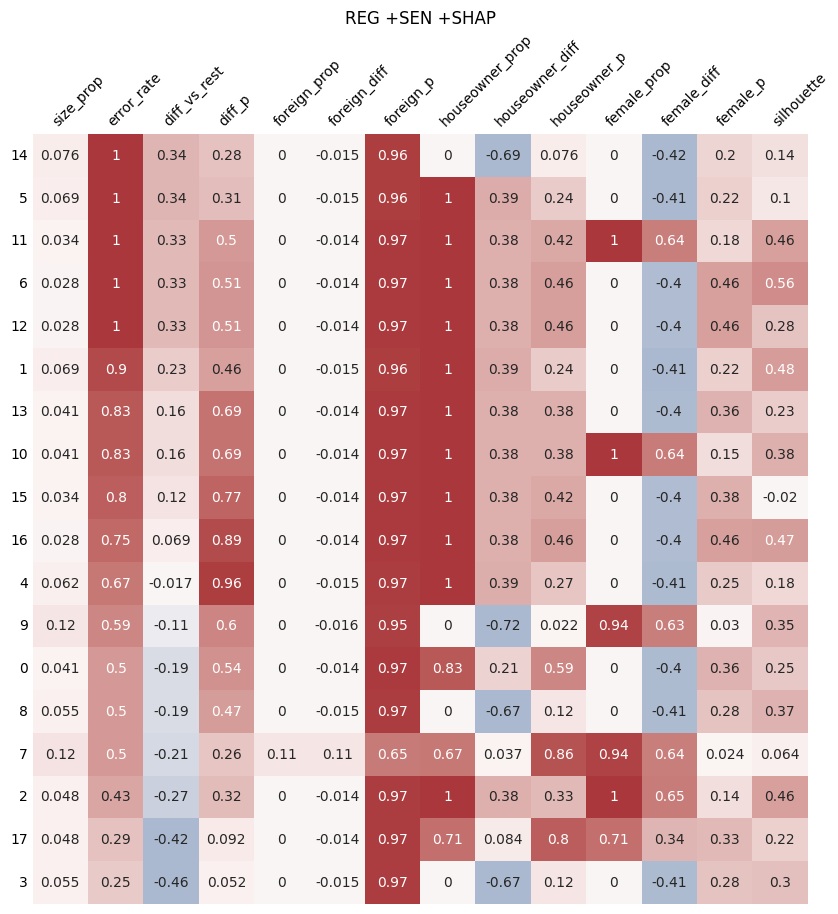

6


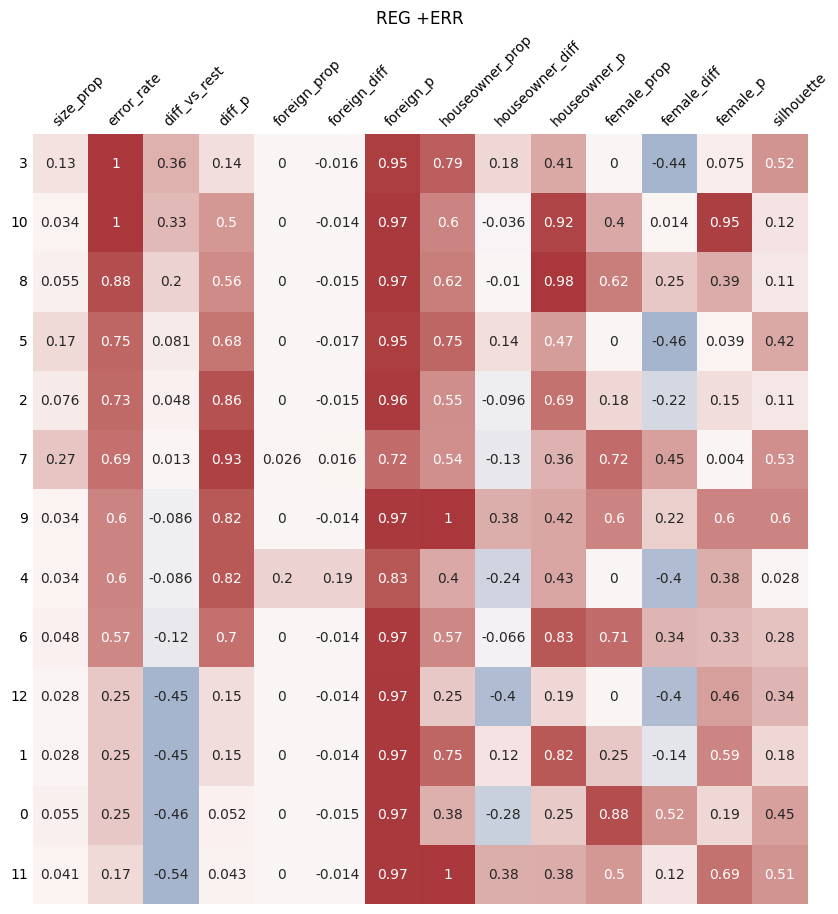

7


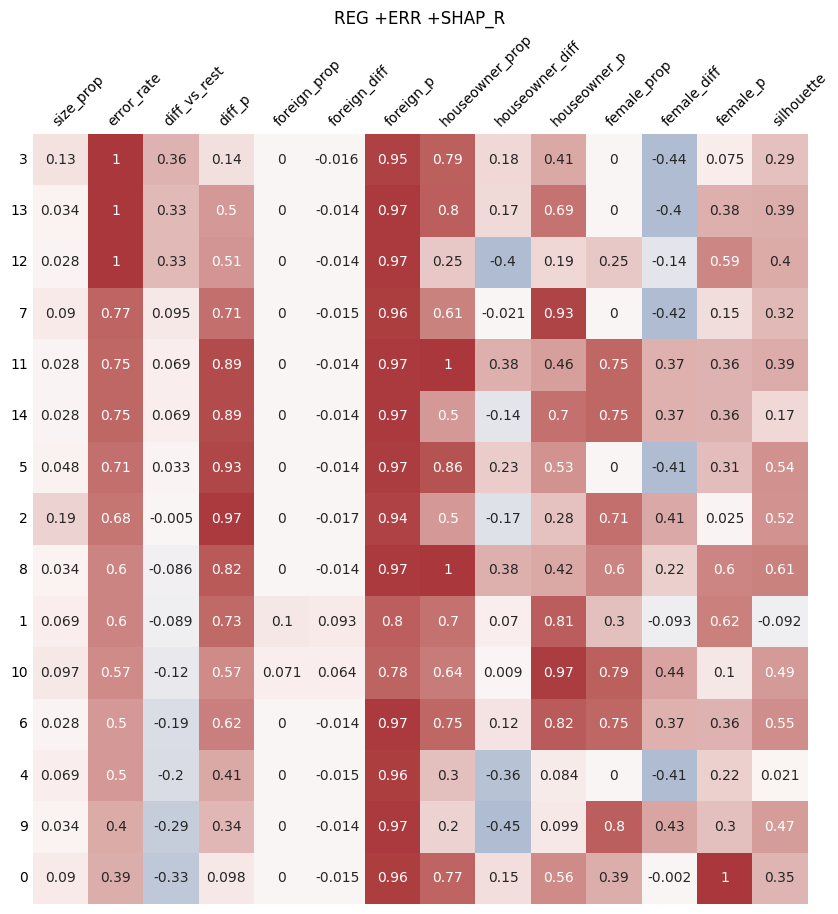

8


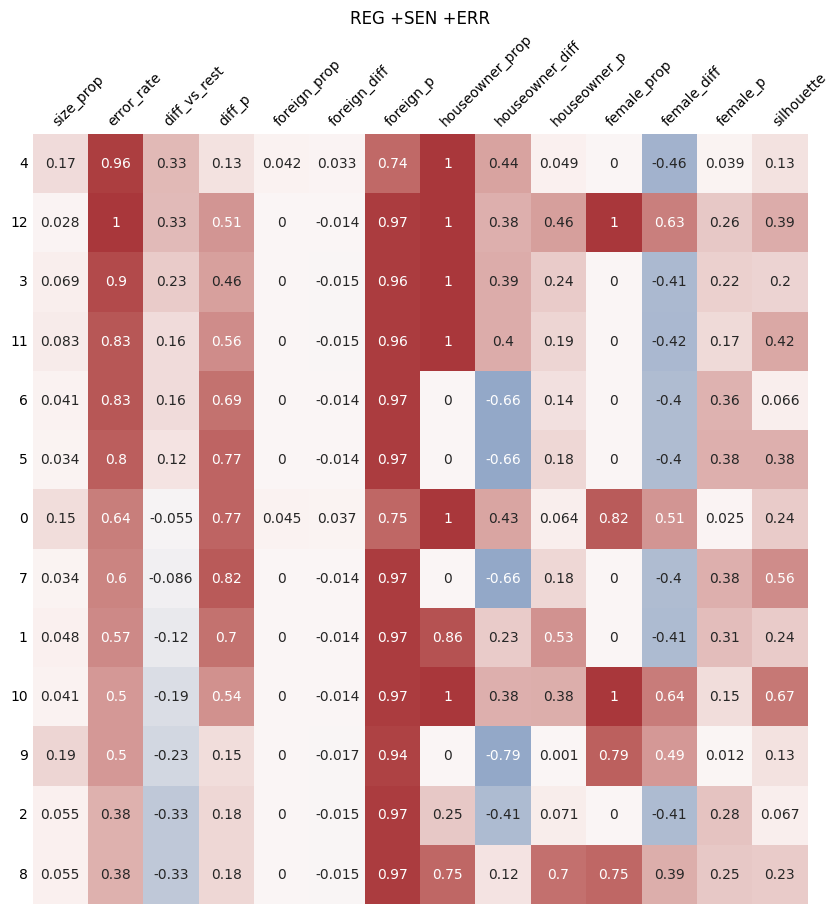

9


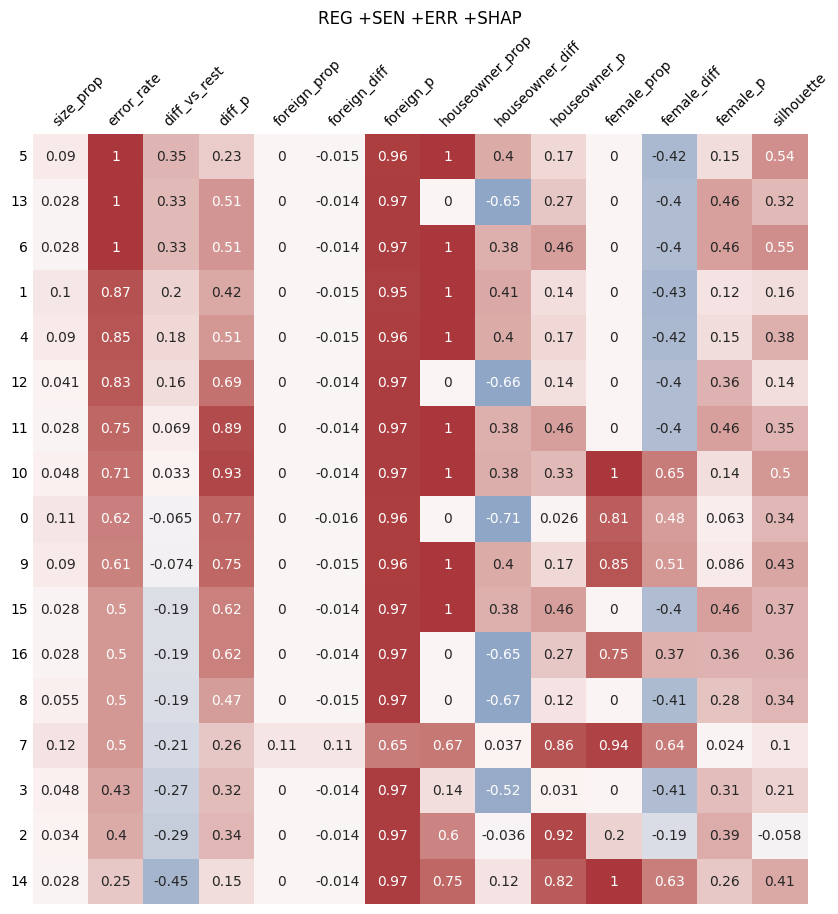

10


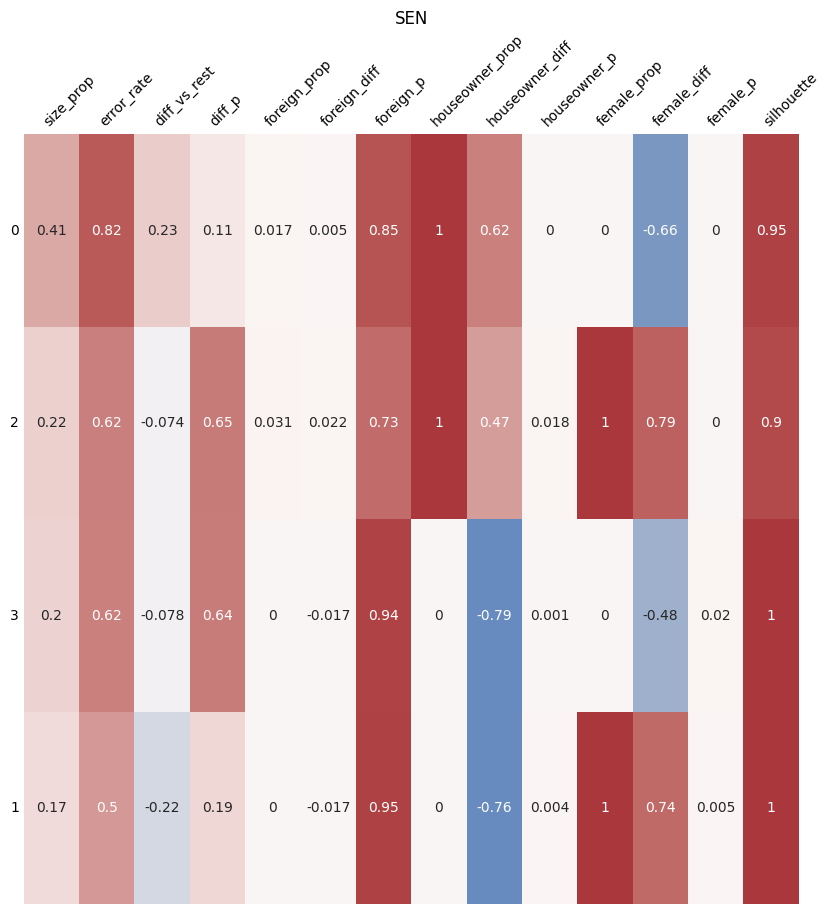

11


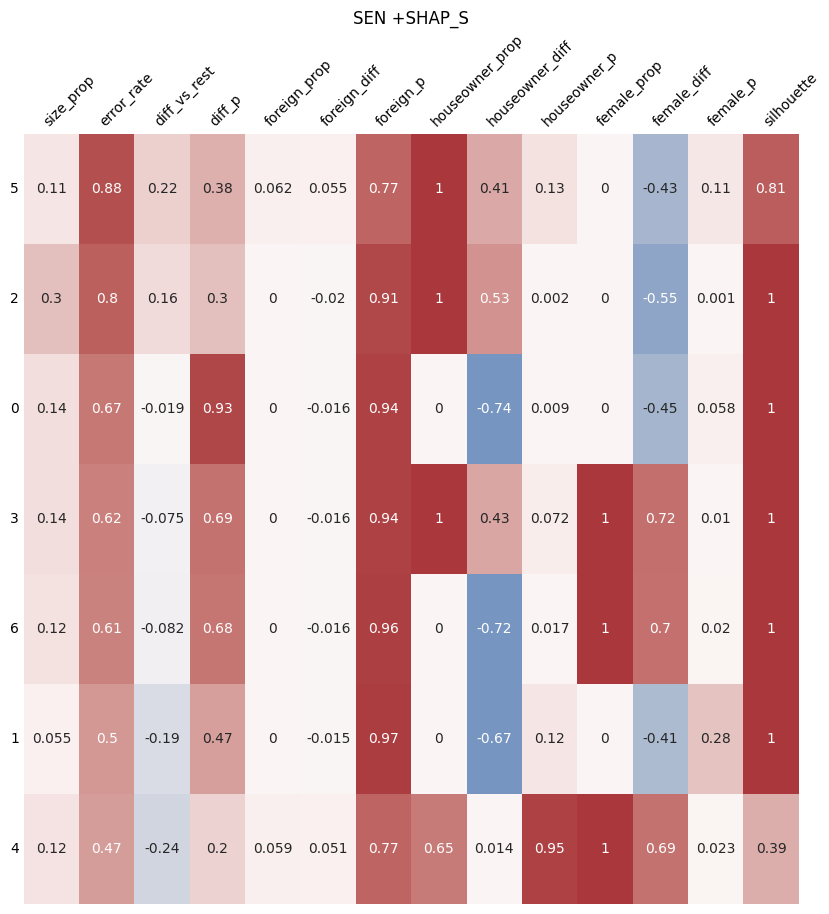

12


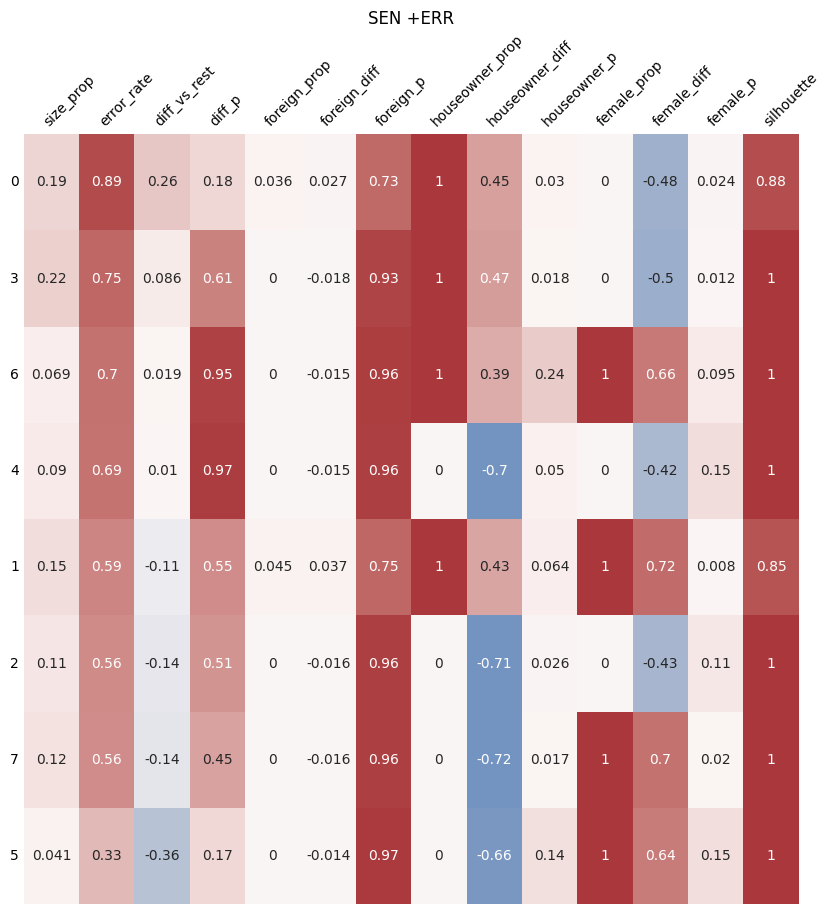

13


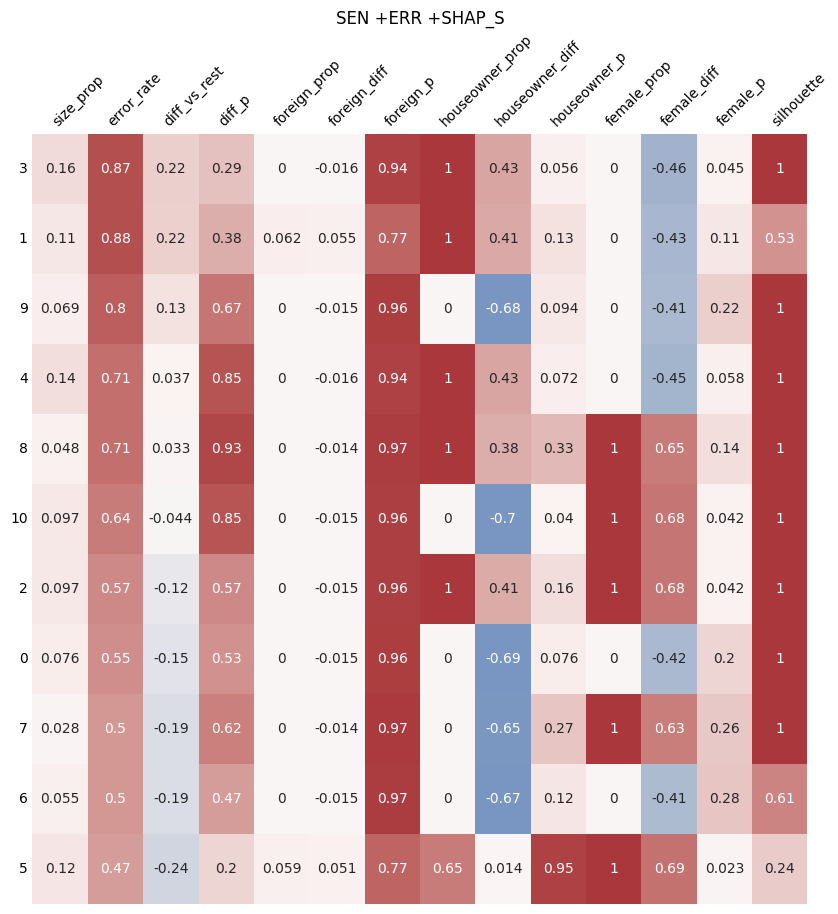

In [28]:
for i in range(0, len(exp_condition)):
  print(i)
  recap = results['cond_recap'][i].sort_values(by=['diff_vs_rest'], ascending=False)
  recap['count'] = recap['count']/recap['count'].sum()
  recap = recap.rename(columns={"count": "size_prop"})
  recap = recap.drop(['n_error','c'], axis=1)

  plt.figure(figsize=(10,10))
  ax = sns.heatmap(recap, annot=True, center=0, cbar=False,
                   cmap=sns.color_palette("vlag", as_cmap=True), robust=True)
  ax.set_title(re.sub(' +', ' ', results['cond_name'][i]))
  ax.xaxis.tick_top()
  ax.set(xlabel="", ylabel="")
  ax.tick_params(axis='x', which='major', length=0)
  ax.tick_params(axis='y', which='major', length=0)
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='left', rotation_mode='anchor')
  plt.yticks(rotation='horizontal')
  plt.savefig('TNFP_Kproto_'+re.sub(' +', '', results['cond_name'][i])+'.png', bbox_inches='tight', pad_inches=0)
  plt.show()

## t-SNE TNFP data

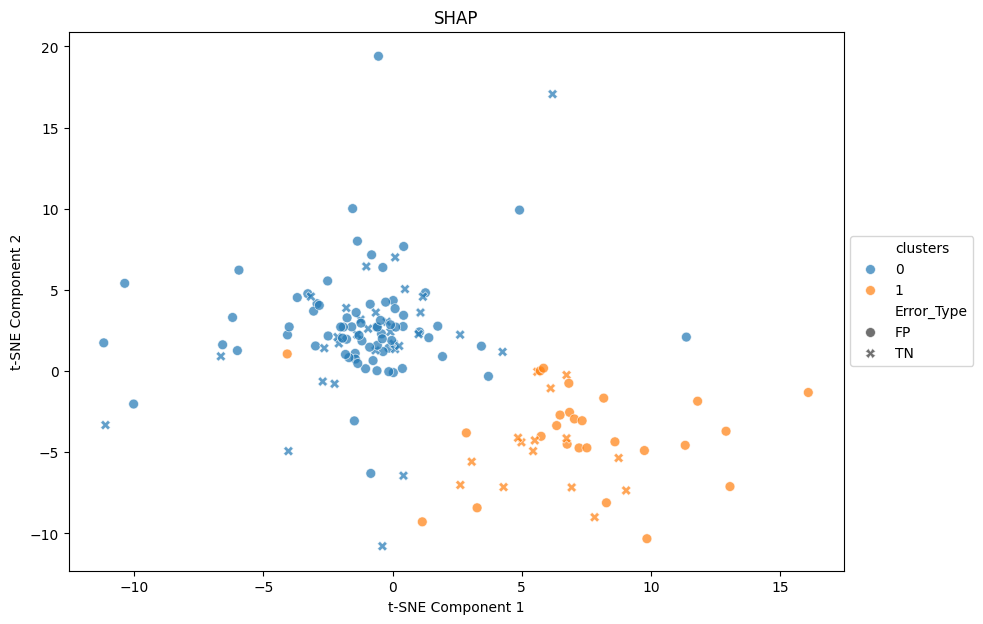

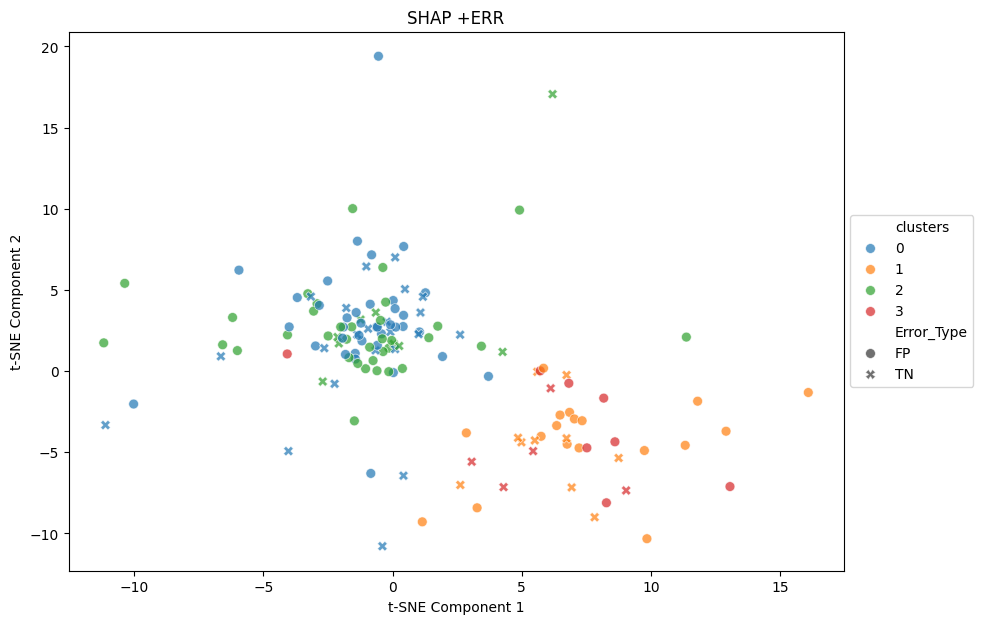

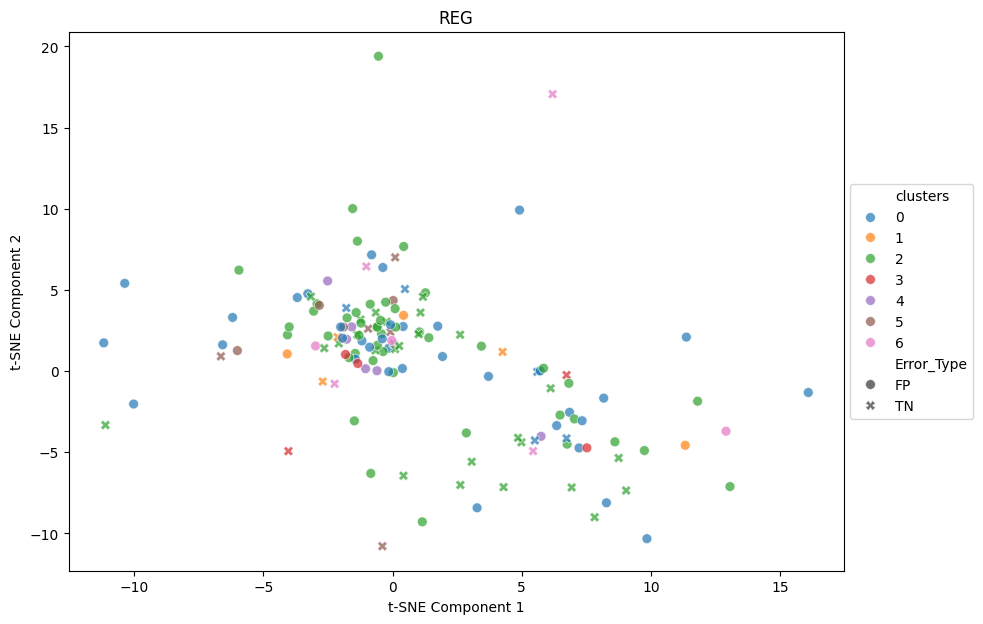

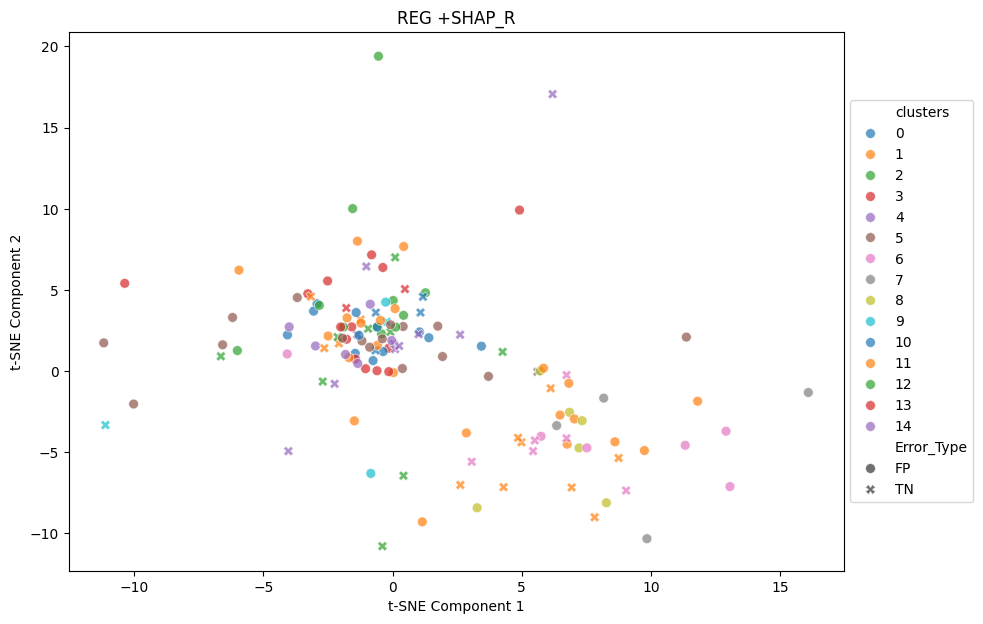

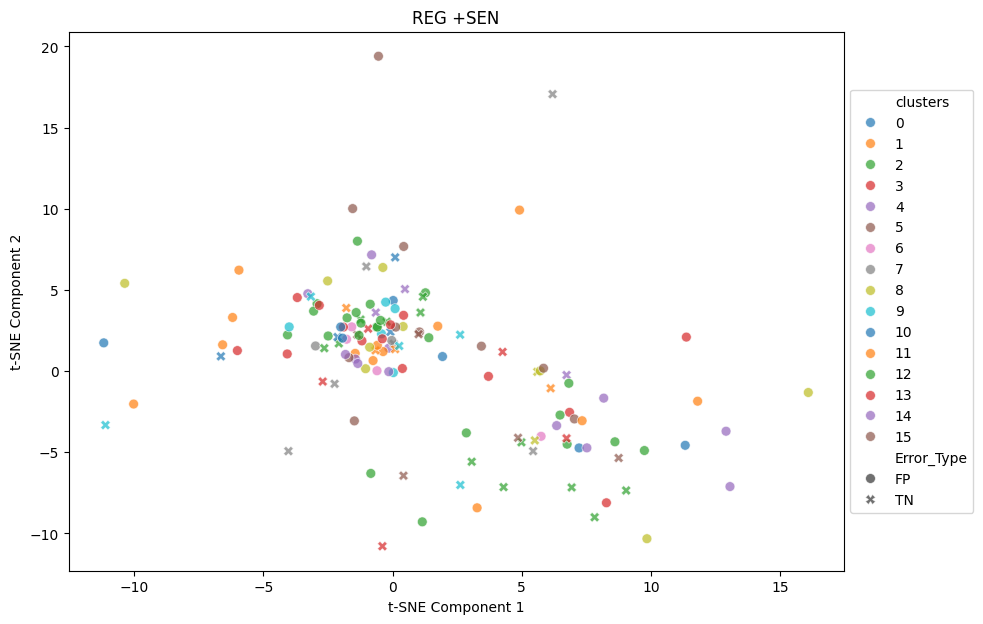

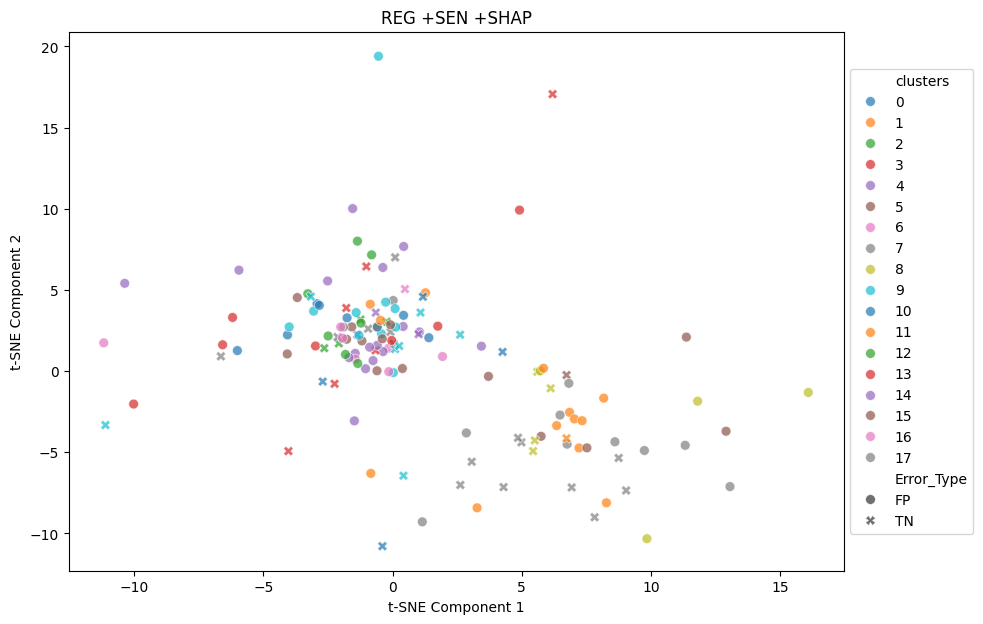

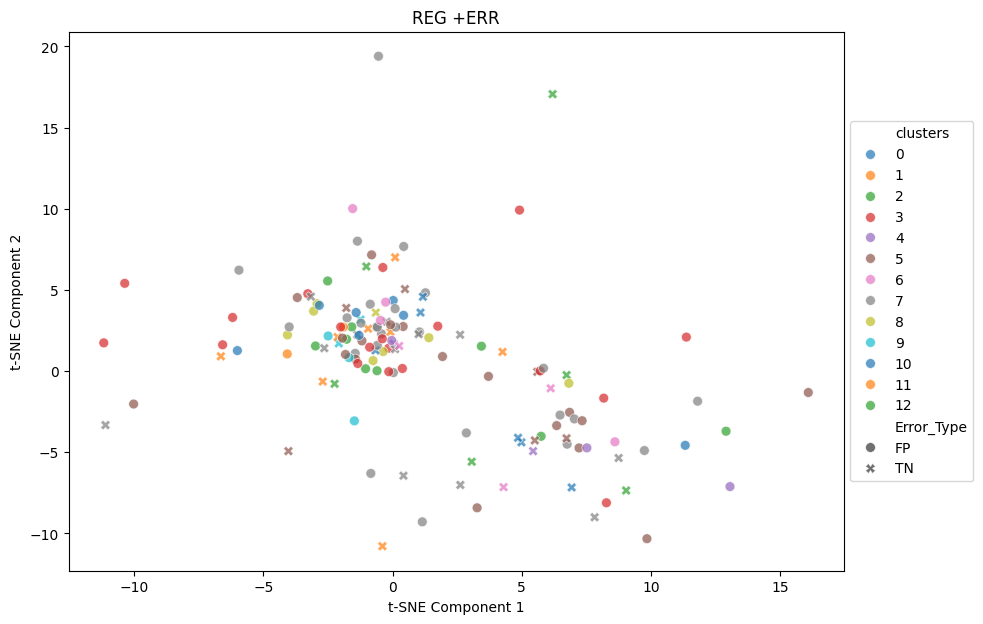

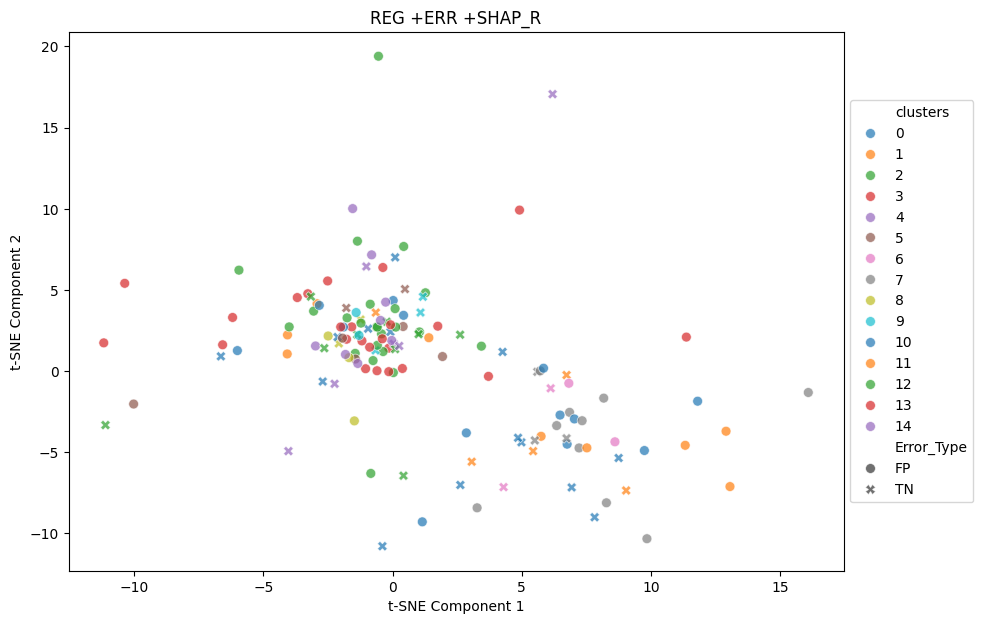

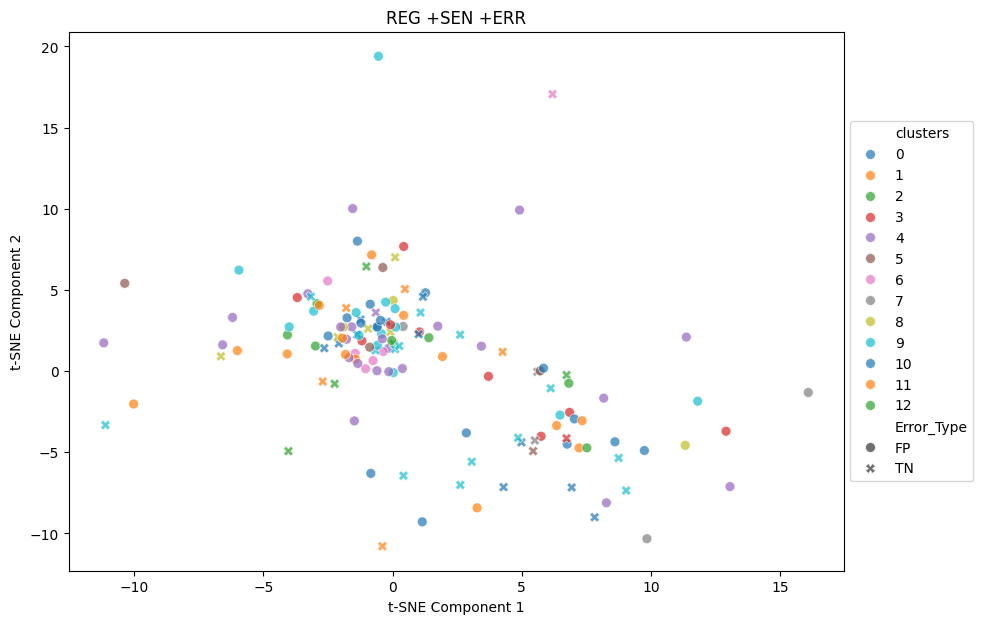

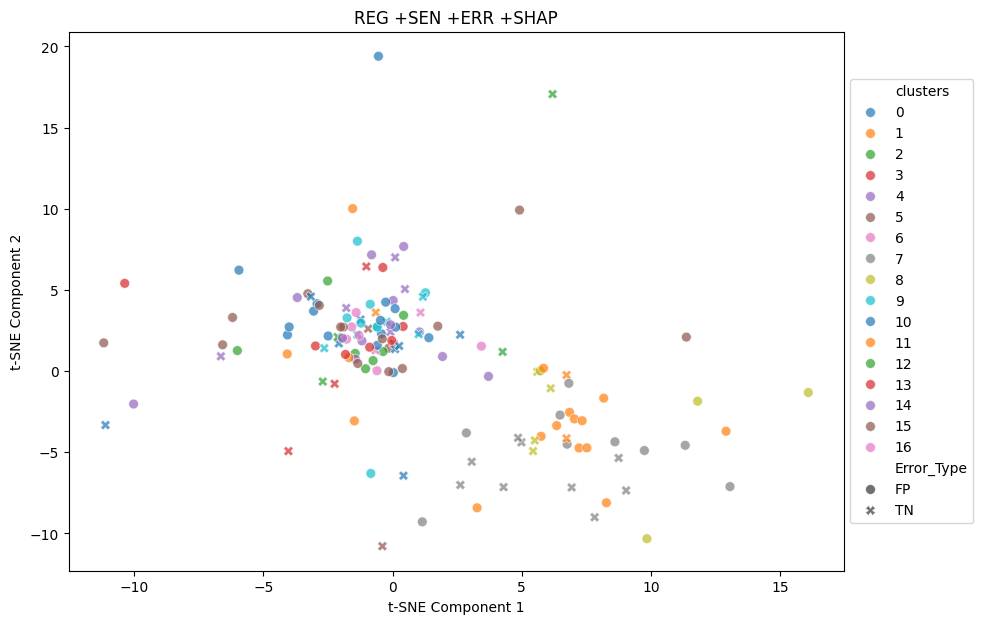

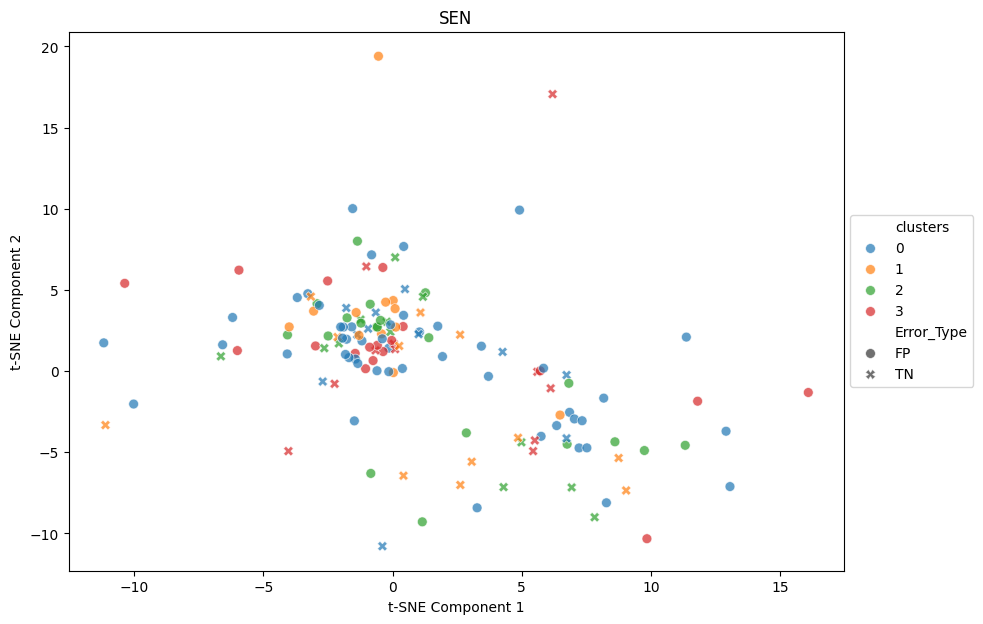

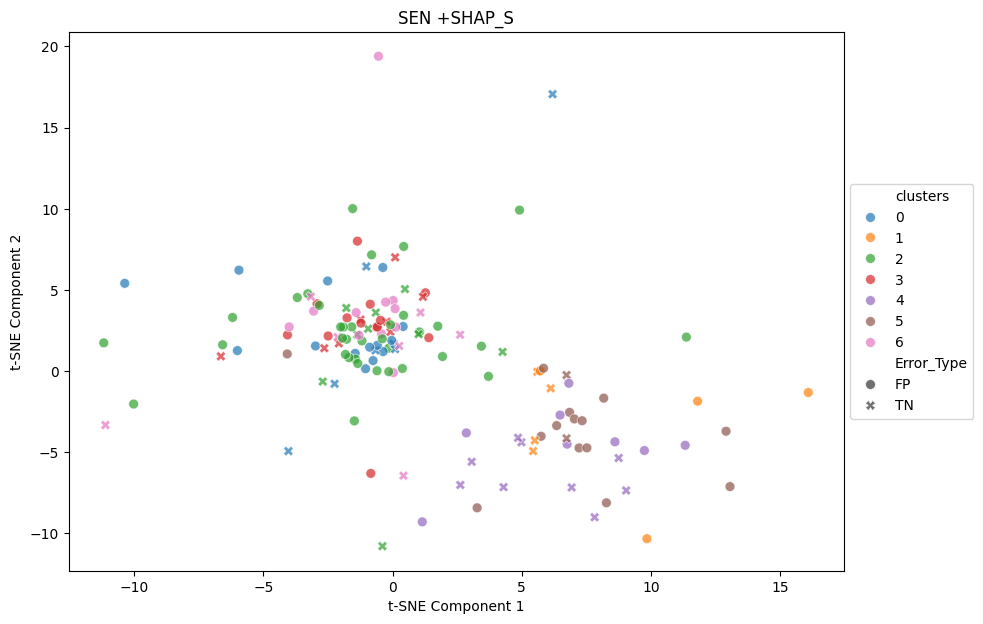

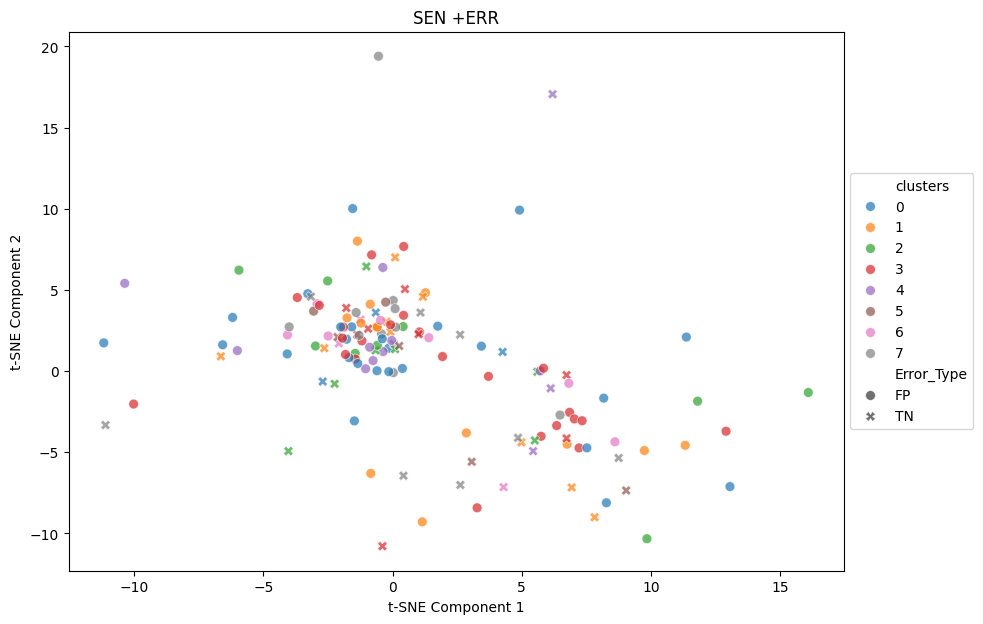

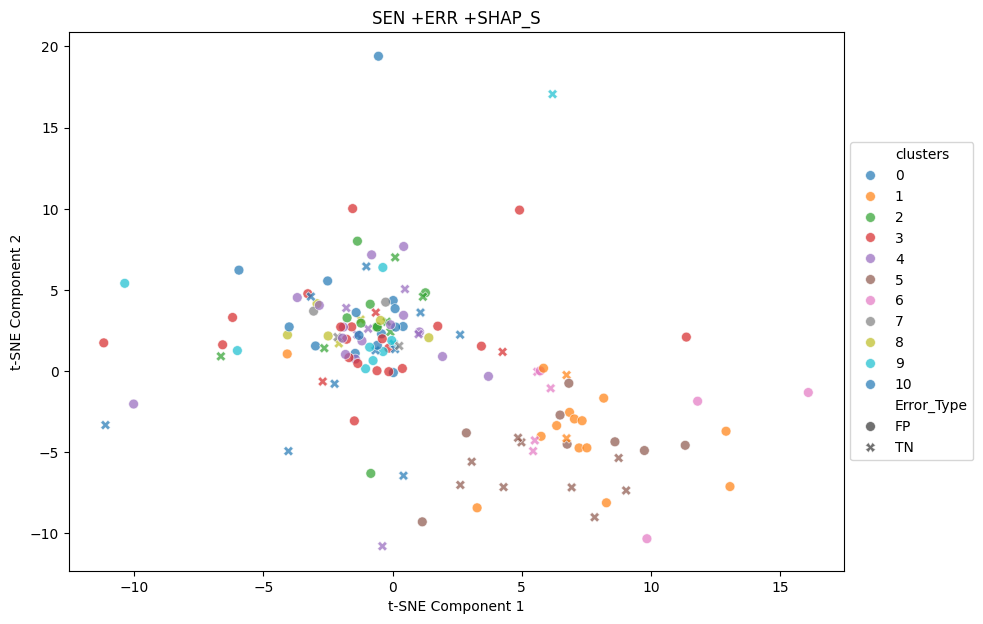

In [29]:
for i in range(0, len(exp_condition)):
  plt.figure(figsize=(10,7))
  tsne_plot_wClusters(results['cond_res'][i], title = re.sub(' +', ' ', results['cond_name'][i]),
                      alpha = 0.7, size = 50,
          tsne_columns = REG_scaled + DUMMY_scaled + SHAP_REG_scaled + SHAP_DUMMY_scaled,
          perplexity = 30, learning_rate = 200, n_iter = 250, fig_prefix='TNFP_Kproto_tSNE_')

# TPFN RESULTS

## Execute Experiments

In [30]:
#hbac parameters
min_splittable_cluster_prop = 0.01
min_acceptable_cluster_prop = 0.03
min_acceptable_error_diff = 0.005

seeds = list(range(10))
all_results = []


#from ctypes import Array
for seed in seeds:
  np.random.seed(seed)
  random.seed(seed)

  results_for_seed = {'cond_name': [],
          'cond_descr': [],
          'cond_res': [],
          'cond_recap': []}

  for i in range(len(exp_condition)):
    res = hbac_proto(TPFN_data.copy(deep=True),
                     columns_to_use = exp_condition['feature_set'][i],
                     exp_condition_name = re.sub(' +', ' ', exp_condition['feature_set_name'][i]),
                     error='errors',
                     min_splittable_cluster_prop = min_splittable_cluster_prop,
                     min_acceptable_cluster_prop = min_acceptable_cluster_prop,
                     min_acceptable_error_diff = min_acceptable_error_diff,
                     max_iter=100,
                     random_state = seed
                     )

    recap = make_recap(res, exp_condition['feature_set'][i])

    results_for_seed['cond_name'].append(exp_condition['feature_set_name'][i])
    results_for_seed['cond_descr'].append(exp_condition['feature_set_descr'][i])
    results_for_seed['cond_res'].append(res)
    results_for_seed['cond_recap'].append(recap)

  all_results.append(results_for_seed)

results = all_results[0]

##Chi-Square Tests TPFN data

In [31]:
chi_dfs = []
quali_dfs = []

for seed_results in all_results:
  chi_df = make_chi_tests(seed_results)
  quali_df = recap_quali_metrics(chi_df, seed_results, exp_condition)

  chi_dfs.append(chi_df)
  quali_dfs.append(quali_df)

chi_all = pd.concat(chi_dfs, ignore_index=True)
quali_all = pd.concat(quali_dfs, ignore_index=True)

chi_summary = chi_all.groupby("cond_name")[['error', 'foreign', 'house', 'gender']].agg(["mean", "std"])
quali_summary = quali_all.groupby("cond_name")[['error', 'foreign', 'house', 'gender', 'silhouette']].agg(["mean", "std"])

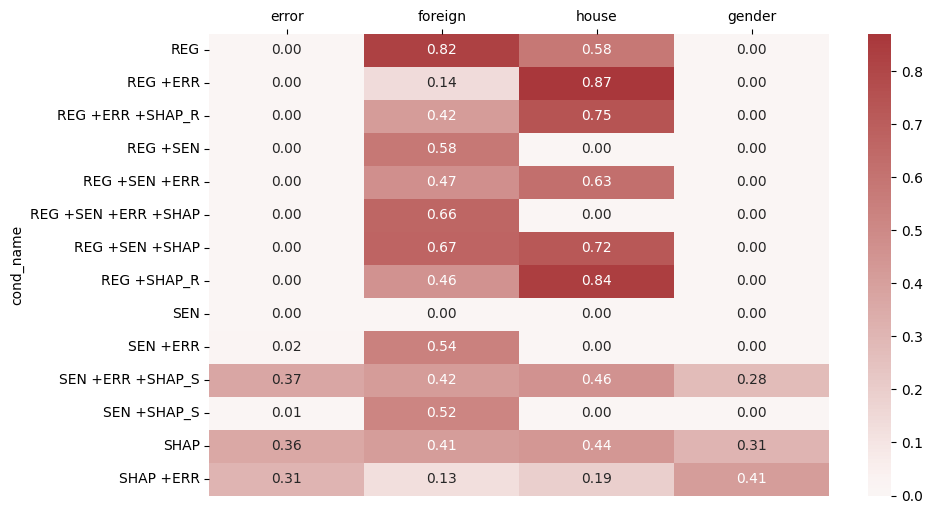

In [32]:
chi_mean = chi_summary.xs('mean', axis=1, level=1)

plt.figure(figsize=(10,6))
ax = sns.heatmap(
    chi_mean,
    annot=True,        # mean values
    fmt='.2f',         # 2 decimals
    center=0,
    cmap=sns.color_palette("vlag", as_cmap=True),
    robust=False
)
ax.xaxis.tick_top()
plt.yticks(rotation='horizontal')
plt.show()

## All Quality Metrics TPFN data

In [33]:
quali_mean_values = quali_summary.xs('mean', axis=1, level=1)
#quali_std_values = quali_summary.xs('std', axis=1, level=1)

# Create a DataFrame for annotations (mean only)
quali_annot_df = pd.DataFrame(index=quali_mean_values.index, columns=quali_mean_values.columns)

for col in quali_mean_values.columns:
    quali_annot_df[col] = [f"{m:.2f}" for m in quali_mean_values[col]]

all_quali_viz = quali_mean_values

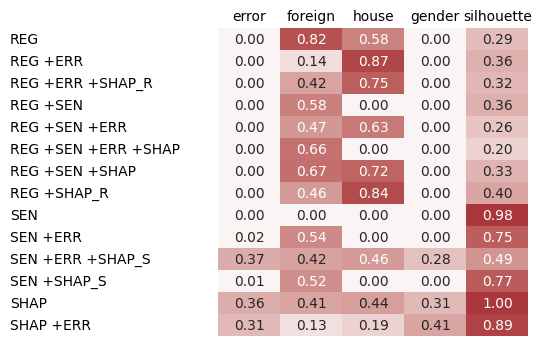

In [34]:
plt.figure(figsize=(4,4))
ax = sns.heatmap(all_quali_viz, annot=quali_annot_df, fmt='', center=0, cbar=False,
                cmap=sns.color_palette("vlag", as_cmap=True), robust=True)
ax.set(xlabel="", ylabel="")
ax.xaxis.tick_top()
ax.tick_params(axis='x', which='major', length=0)
ax.tick_params(axis='y', which='major', pad=150, length=0)
plt.yticks(ha='left')
plt.savefig('TPFN_Kproto.png', bbox_inches='tight', pad_inches=0)
#files.download('TPFN_Kproto.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

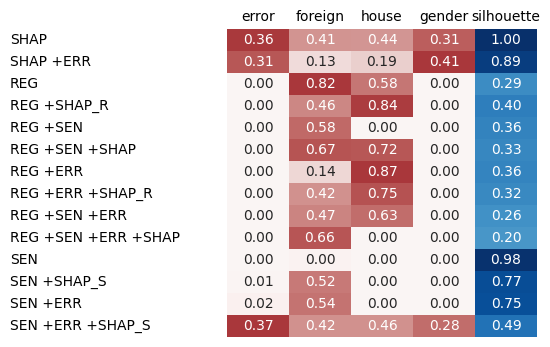

In [35]:
fig, axes = plt.subplots(1, len(all_quali_viz.columns), figsize=(4, 4), sharey=True)

colormap_dict = {
    'error': 'vlag',
    'foreign': 'vlag',
    'house': 'vlag',
    'gender': 'vlag',
    'silhouette': 'Blues'
}

# Reindex all_quali_viz and quali_annot_df to match the order in exp_condition
ordered_cond_names = exp_condition['feature_set_name'].tolist()
all_quali_viz_ordered = all_quali_viz.reindex(ordered_cond_names)
quali_annot_df_ordered = quali_annot_df.reindex(ordered_cond_names)

# Iterate through columns and apply colormaps individually
for i, column in enumerate(all_quali_viz_ordered.columns):
    sns.heatmap(
        all_quali_viz_ordered[[column]],  # Select a single column for each iteration
        annot=quali_annot_df_ordered[[column]], # Use the formatted annotations
        fmt='',                    # No default formatting needed as annot is already formatted
        center=0,
        cmap=colormap_dict[column],  # Use the appropriate colormap from the dictionary
        robust=True,
        cbar=False,
        ax=axes[i],  # Use the corresponding subplot
        xticklabels=False,
        #annot_kws={"size": 8}
    )

    axes[i].set_title(column, size = 10)  # Set title for each subplot
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")  # Remove y-axis label (cond_name)
    axes[i].set_yticks([])

    # Add condition names as text labels on the left
    if i == 0: # Only add labels to the first subplot
        for j, cond_name in enumerate(all_quali_viz_ordered.index):
            axes[i].text(-3.5, j + 0.5, cond_name, ha='left', va='center')


plt.subplots_adjust(wspace=0)

# Save the figure
plt.savefig("TPFN_KPrototypes_credit_new.png", bbox_inches="tight", pad_inches=0)
files.download('TPFN_KPrototypes_credit_new.png')
# Show the plot
plt.show()

# DETAILED TPFN data


## One-vs-All cluster comparison TPFN data

0


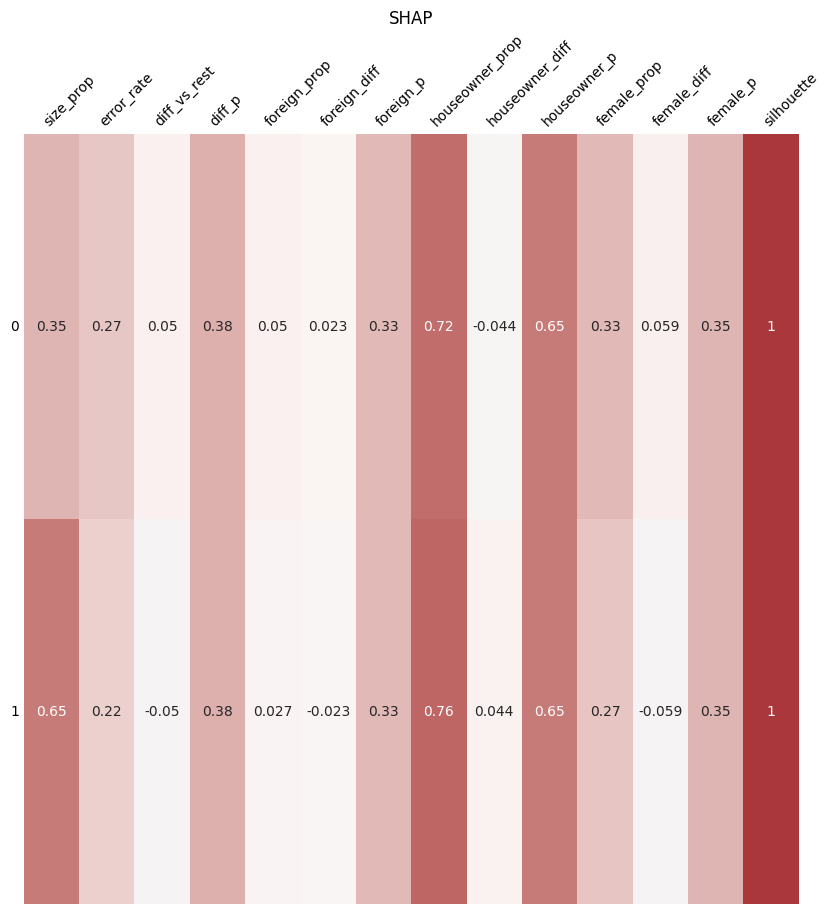

1


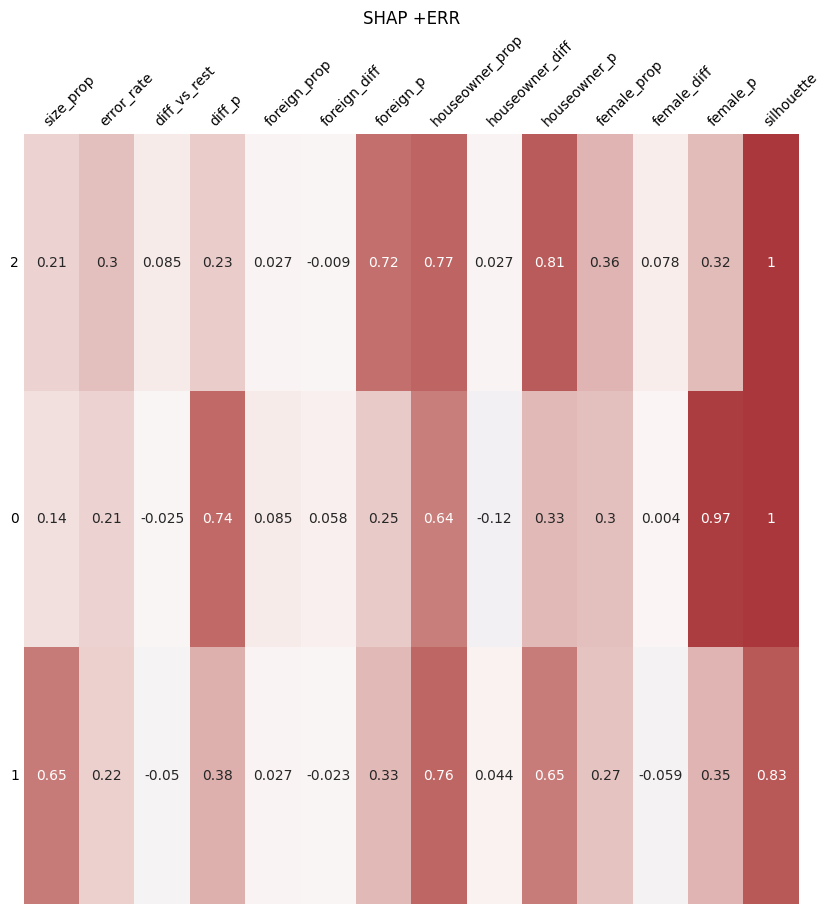

2


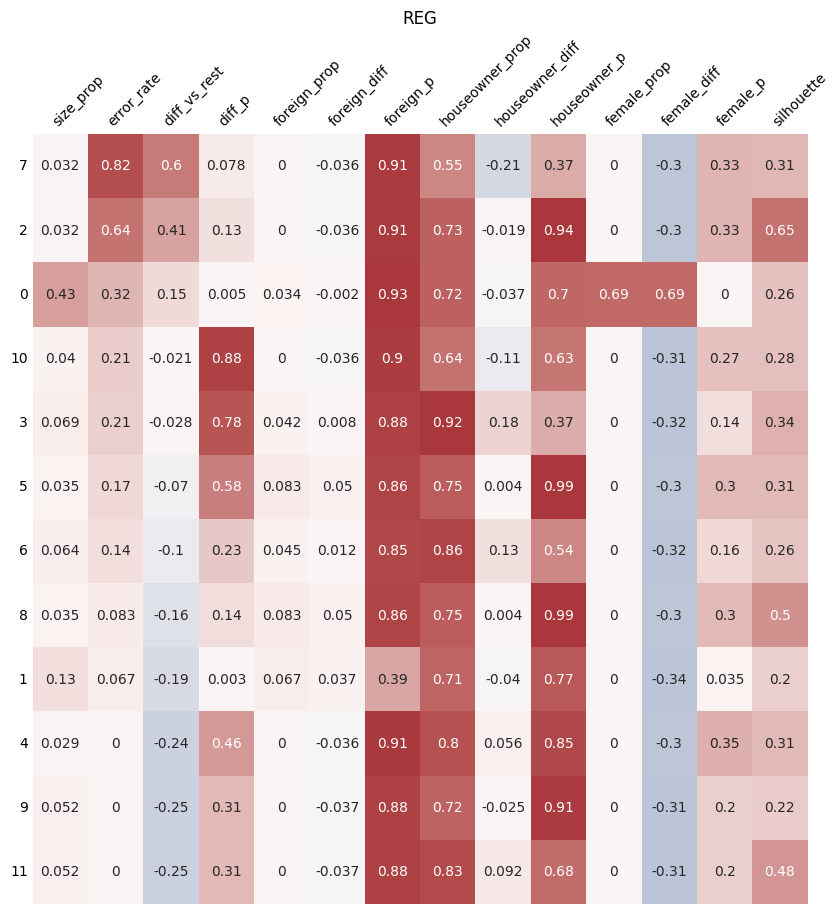

3


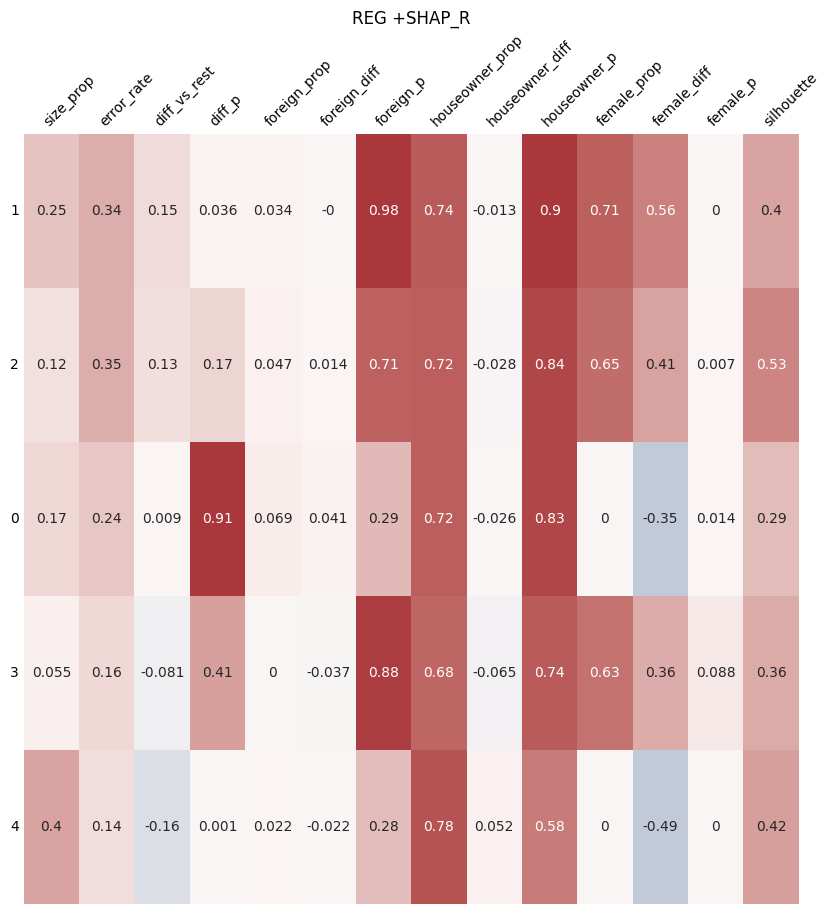

4


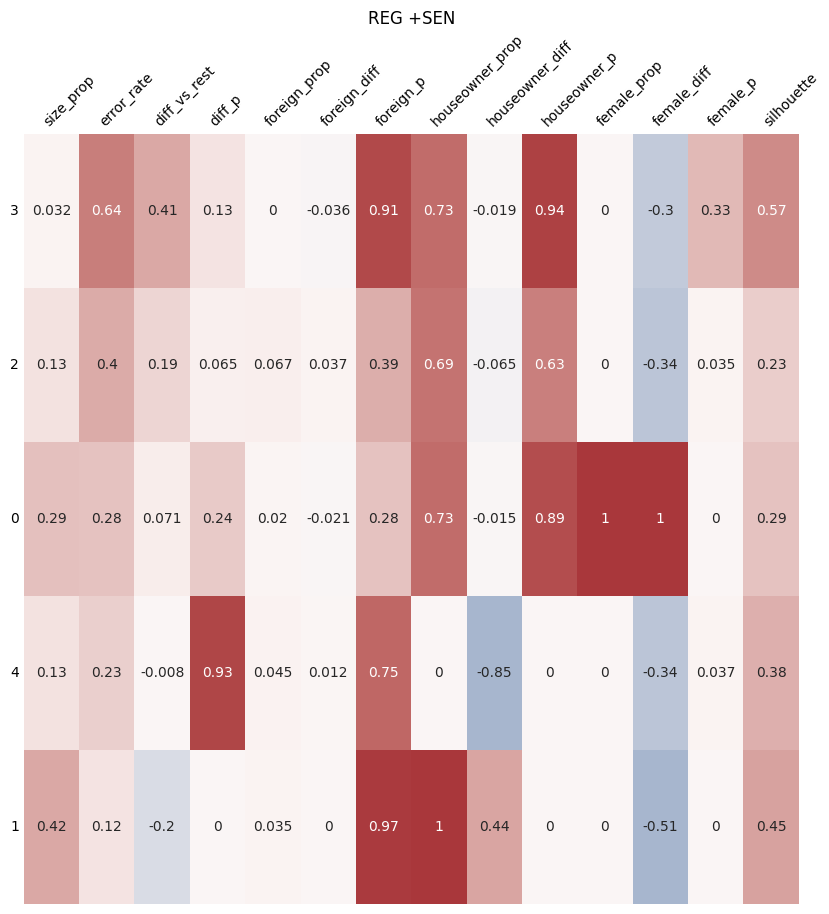

5


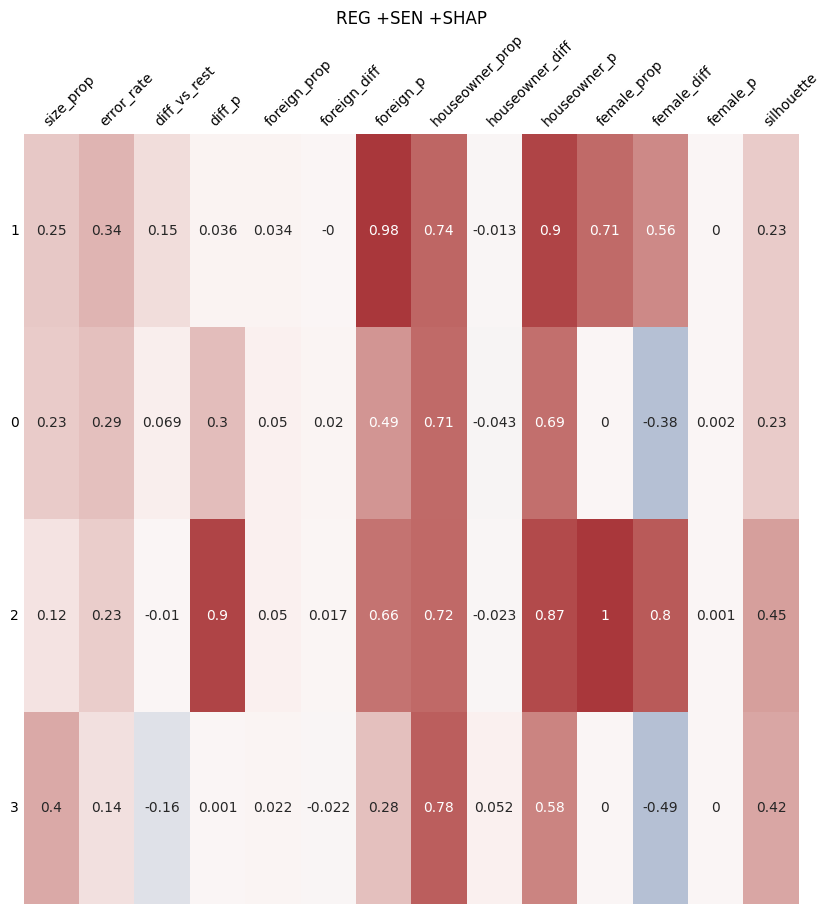

6


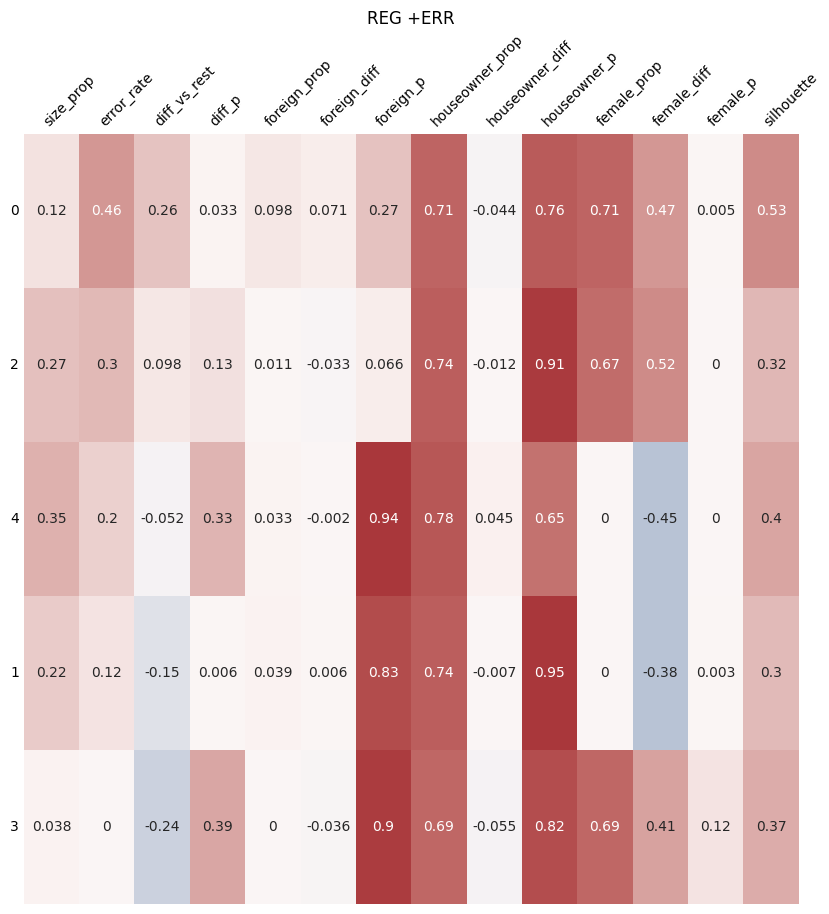

7


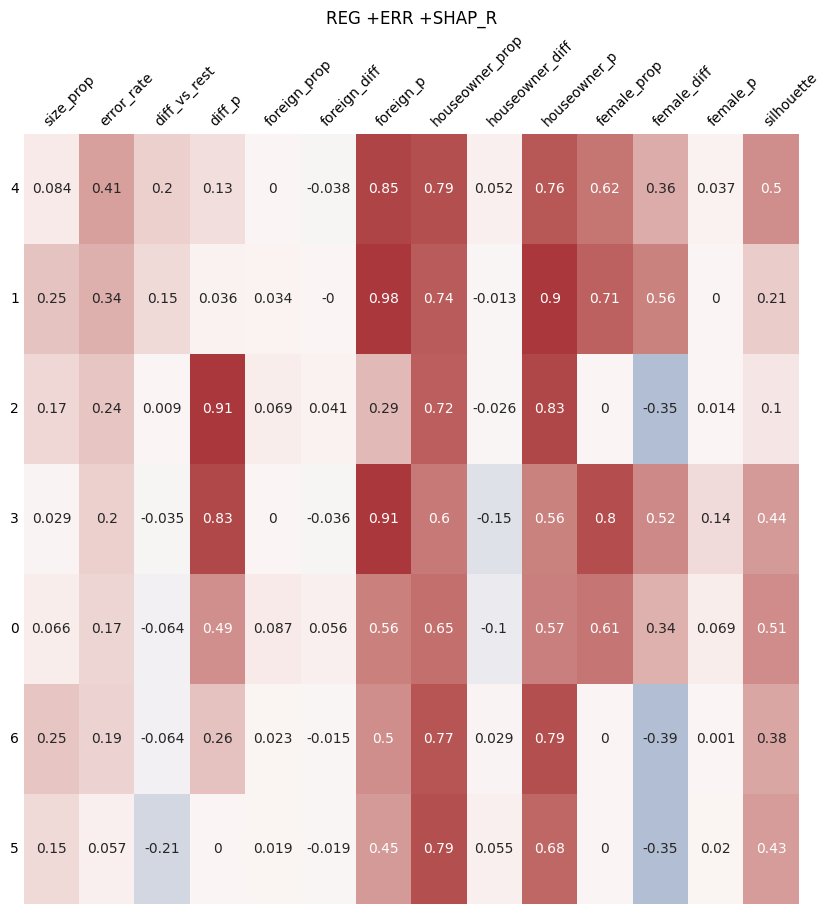

8


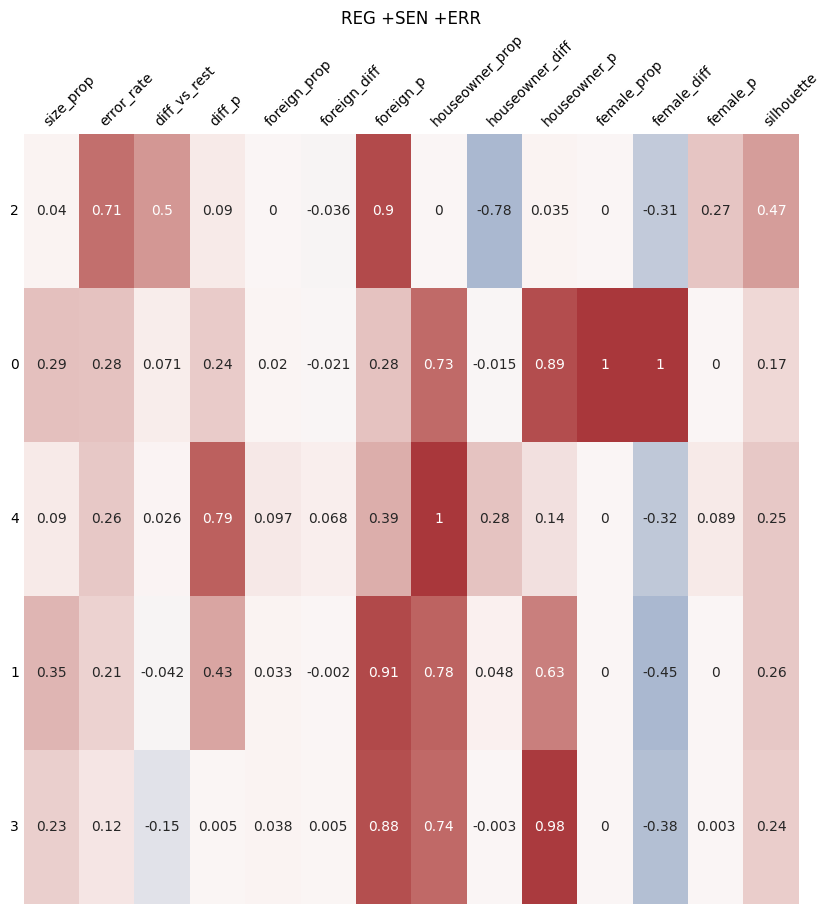

9


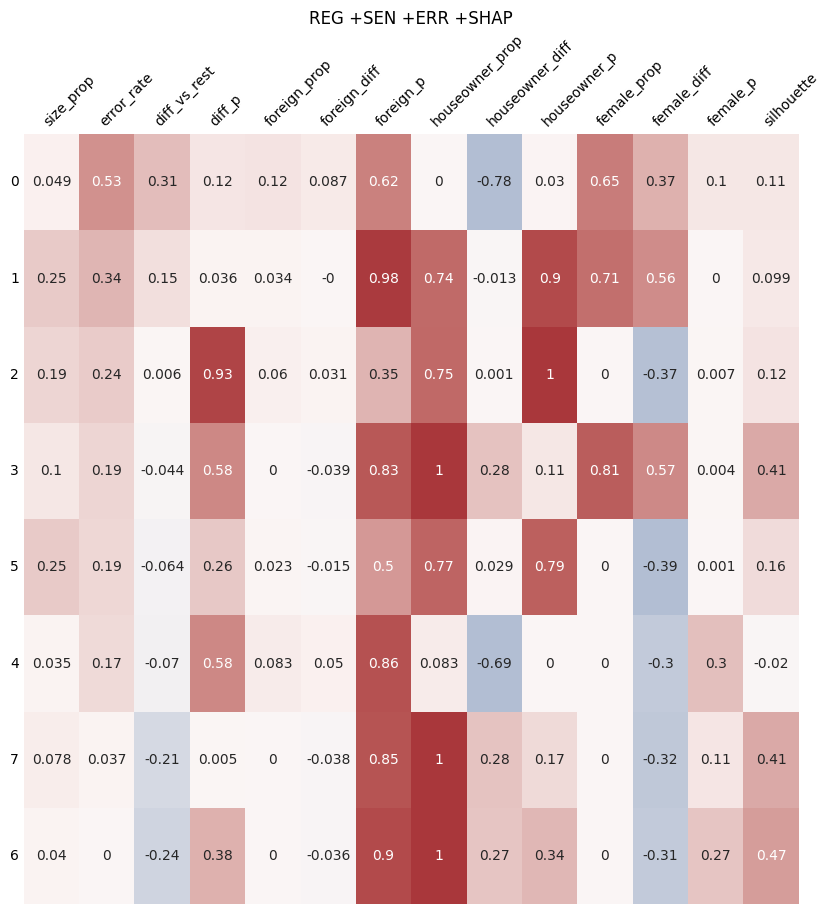

10


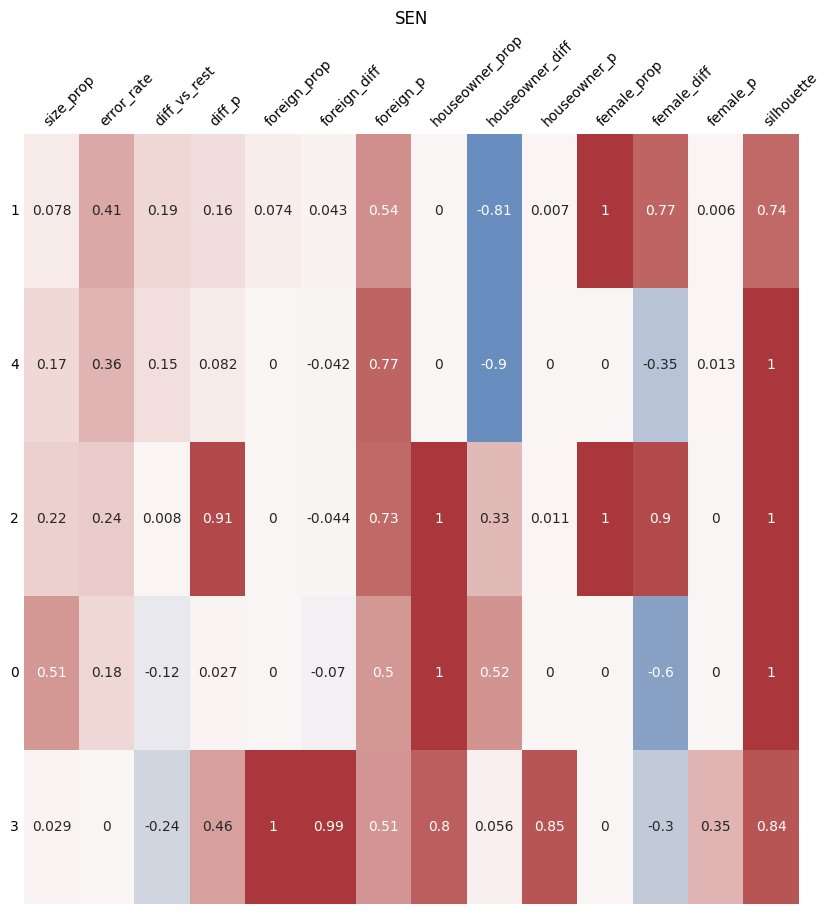

11


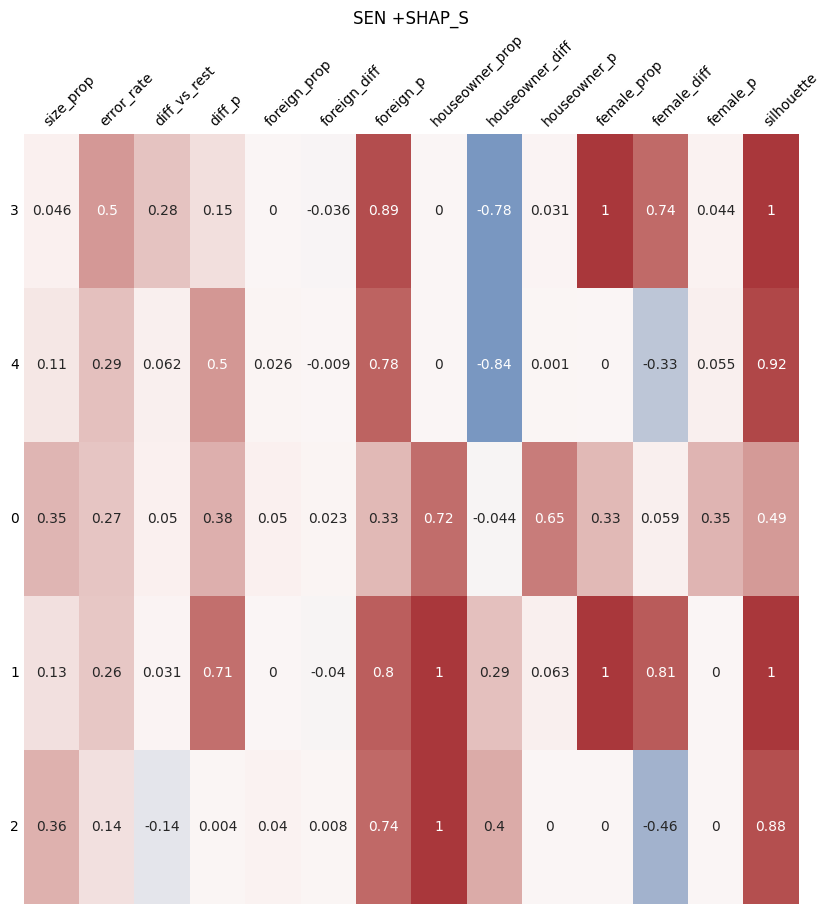

12


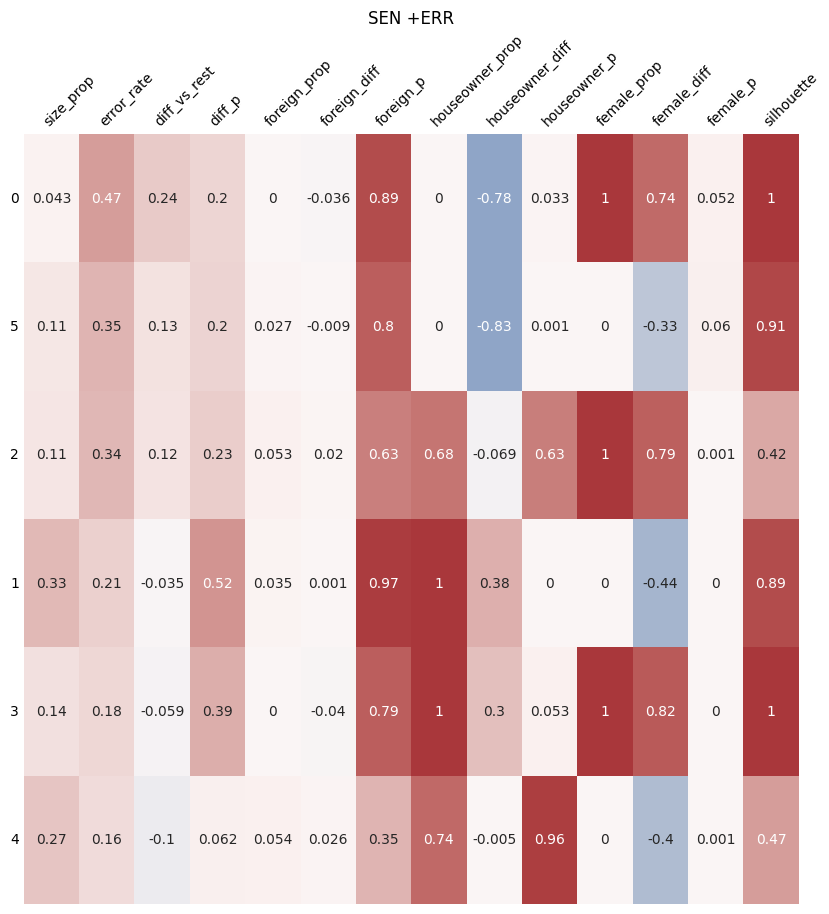

13


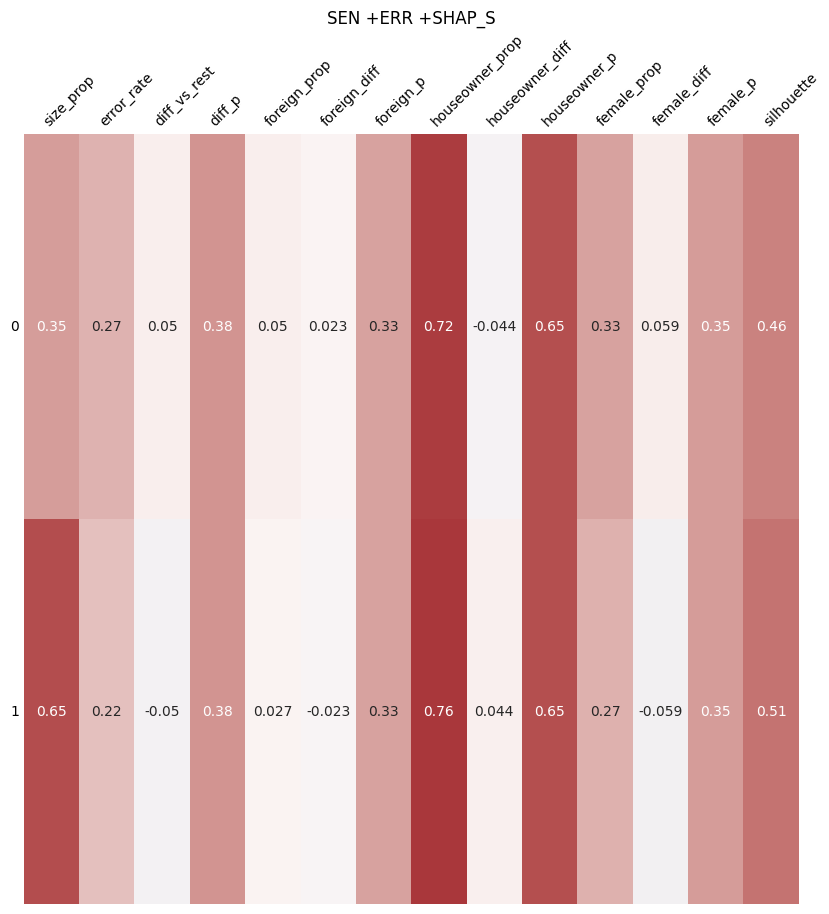

In [36]:
for i in range(0, len(exp_condition)):
  print(i)
  recap = results['cond_recap'][i].sort_values(by=['diff_vs_rest'], ascending=False)
  recap['count'] = recap['count']/recap['count'].sum()
  recap = recap.rename(columns={"count": "size_prop"})
  recap = recap.drop(['n_error','c'], axis=1)

  plt.figure(figsize=(10,10))
  ax = sns.heatmap(recap, annot=True, center=0, cbar=False,
                   cmap=sns.color_palette("vlag", as_cmap=True), robust=True)
  ax.set_title(re.sub(' +', ' ', results['cond_name'][i]))
  ax.xaxis.tick_top()
  ax.set(xlabel="", ylabel="")
  ax.tick_params(axis='x', which='major', length=0)
  ax.tick_params(axis='y', which='major', length=0)
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='left', rotation_mode='anchor')
  plt.yticks(rotation='horizontal')
  plt.savefig('TPFN_Kproto_'+re.sub(' +', '', results['cond_name'][i])+'.png', bbox_inches='tight', pad_inches=0)
  plt.show()

## t-SNE TPFN data

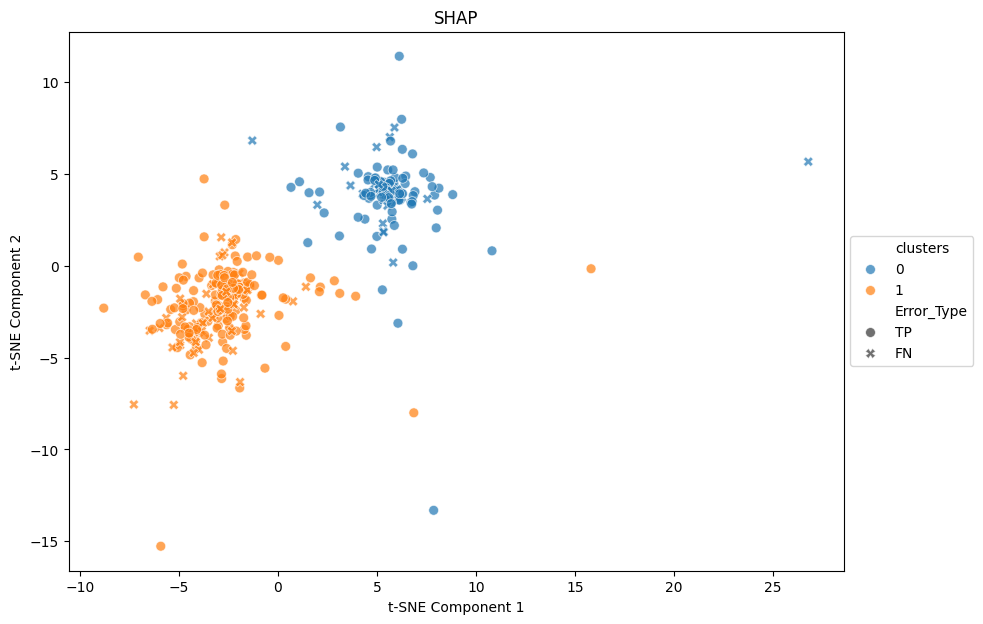

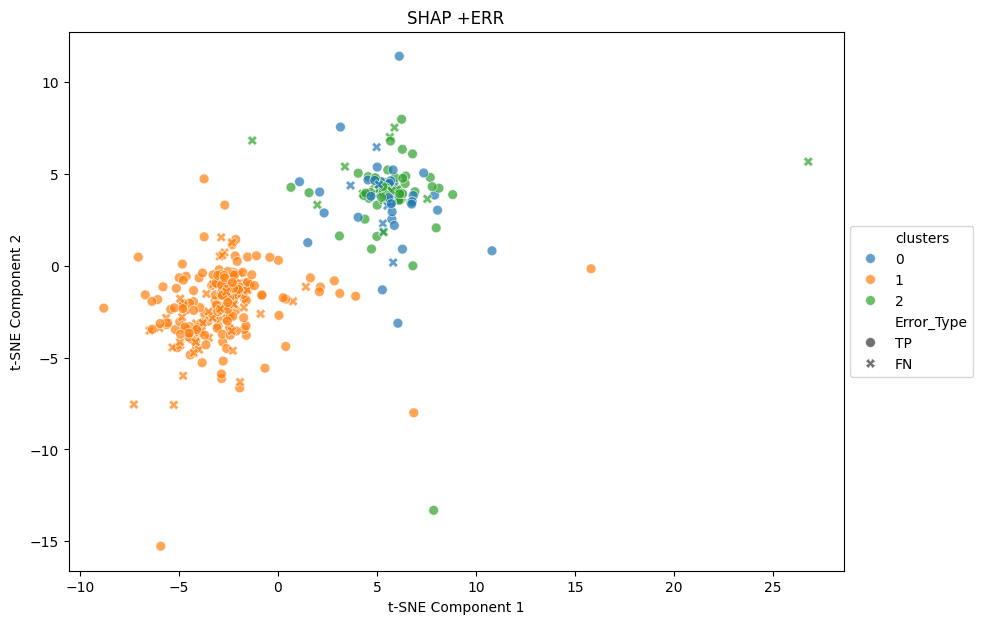

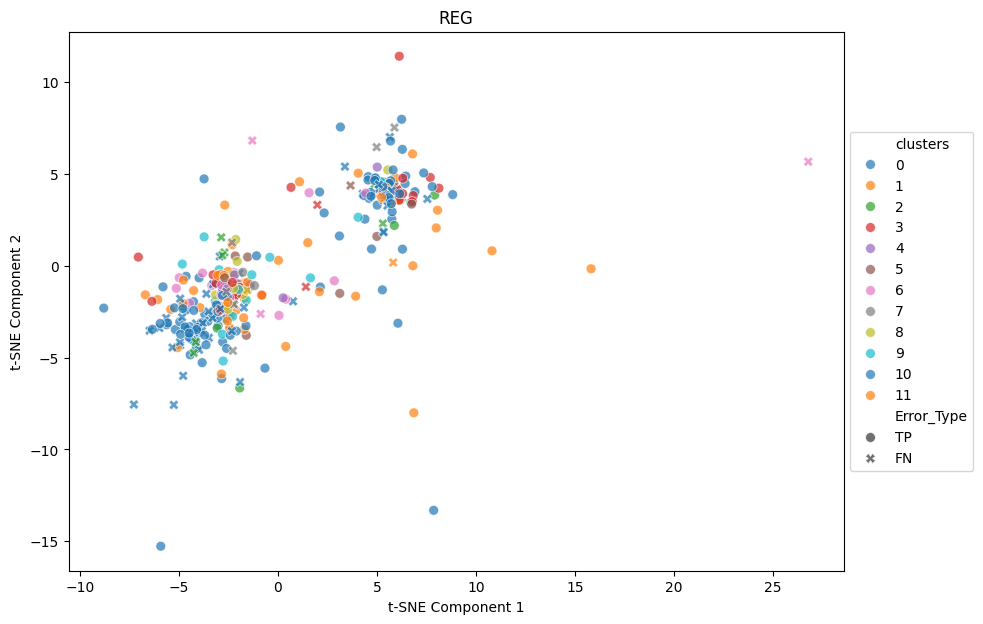

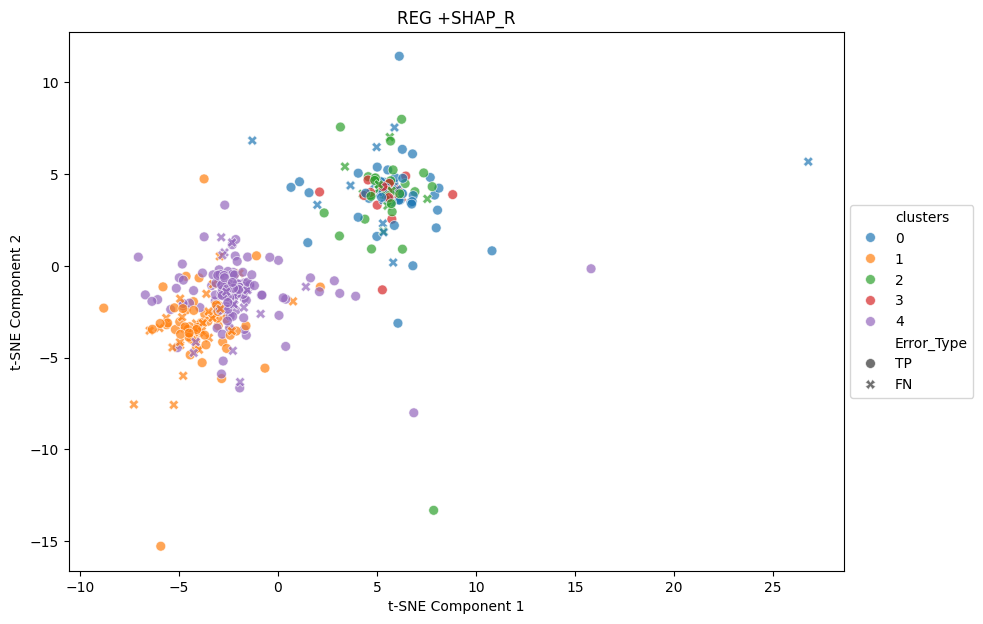

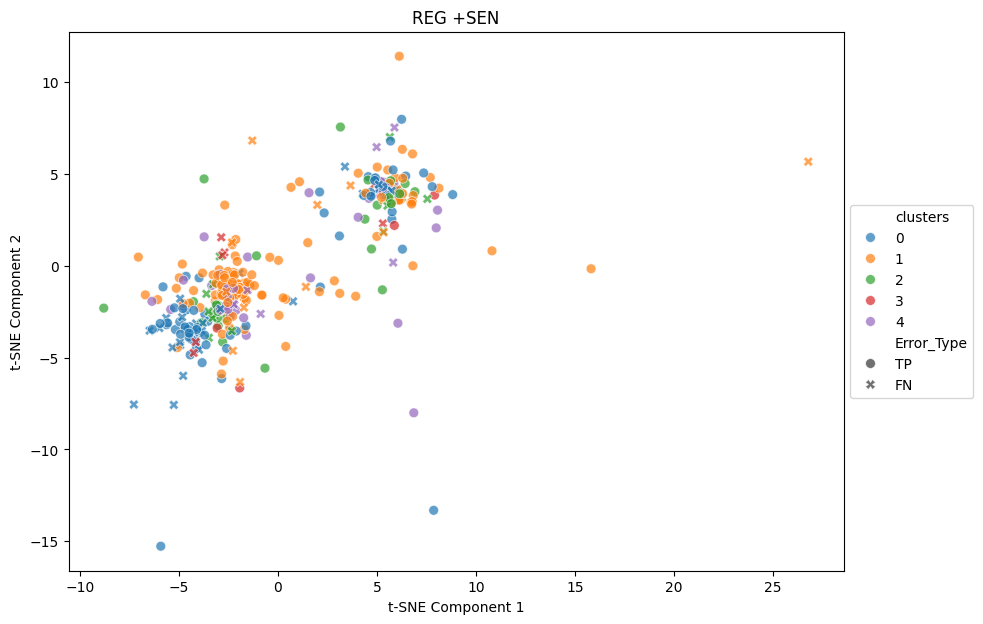

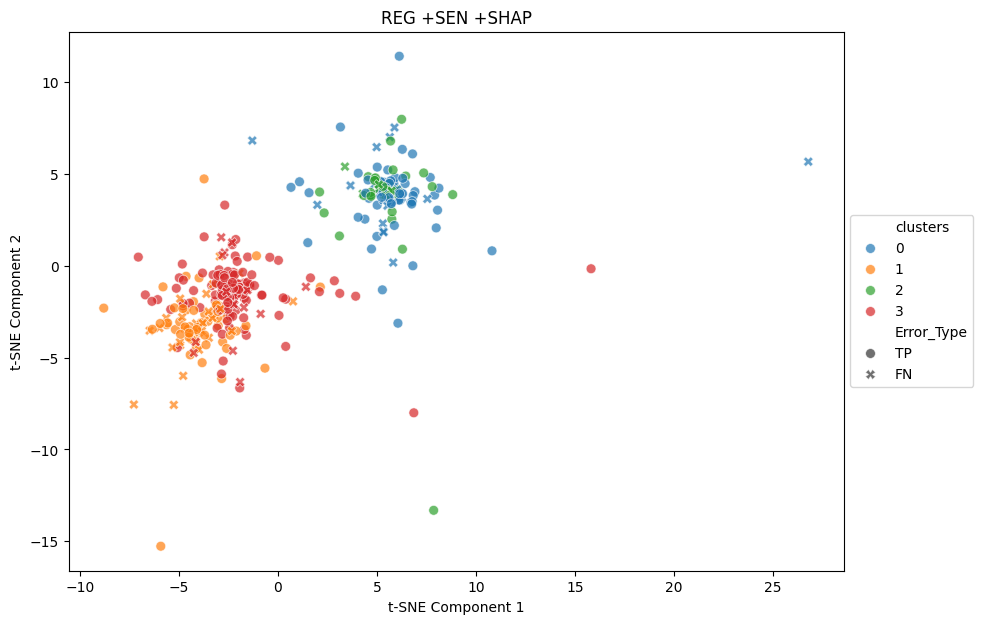

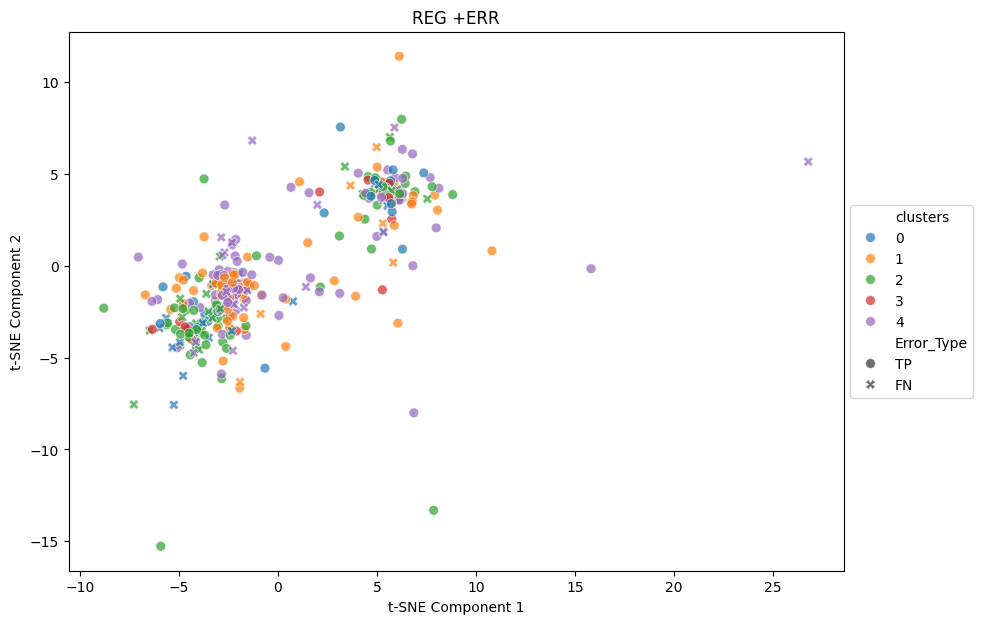

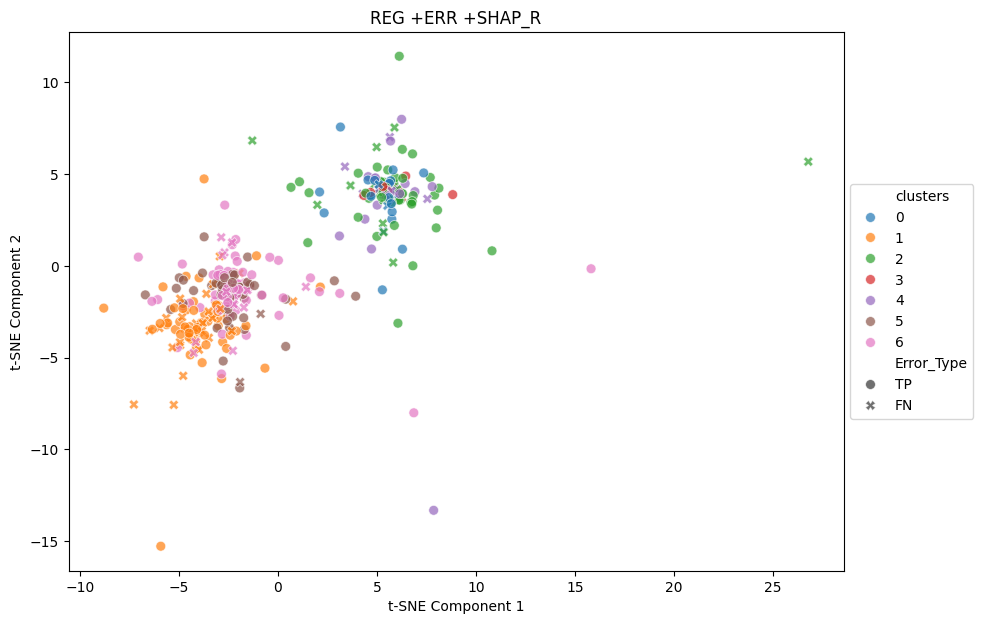

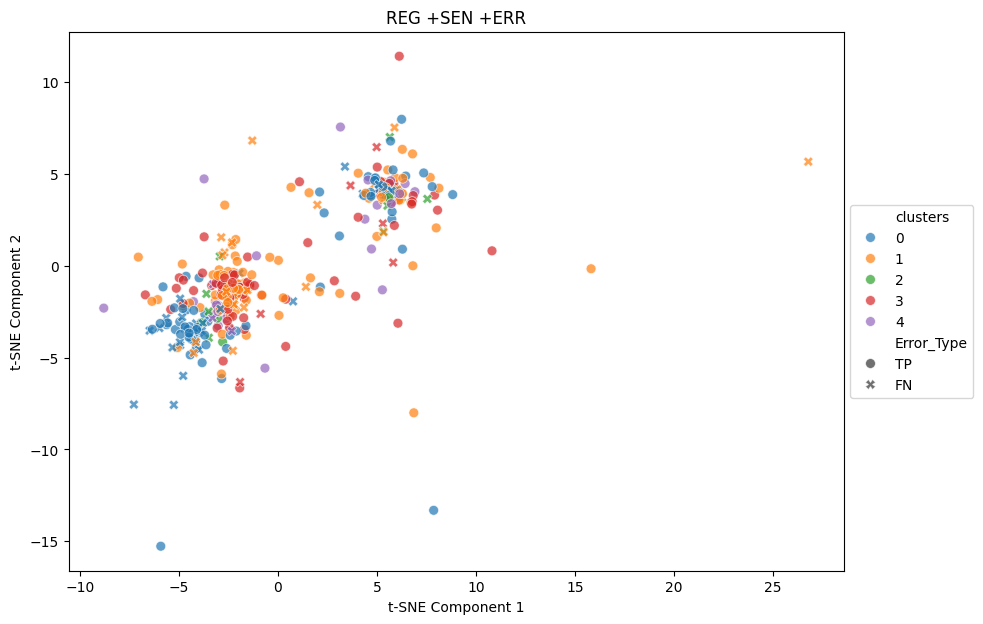

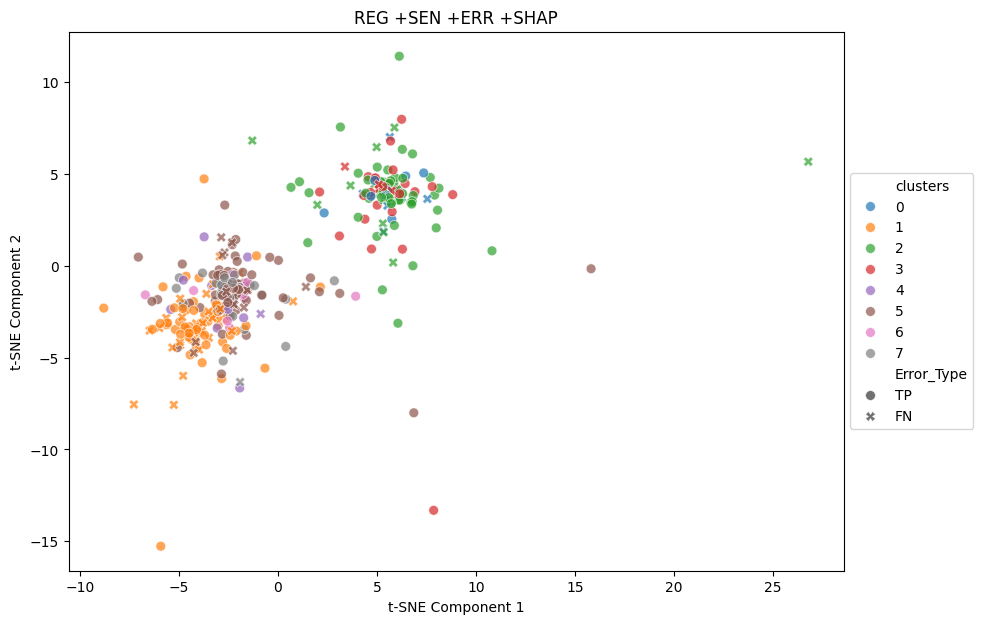

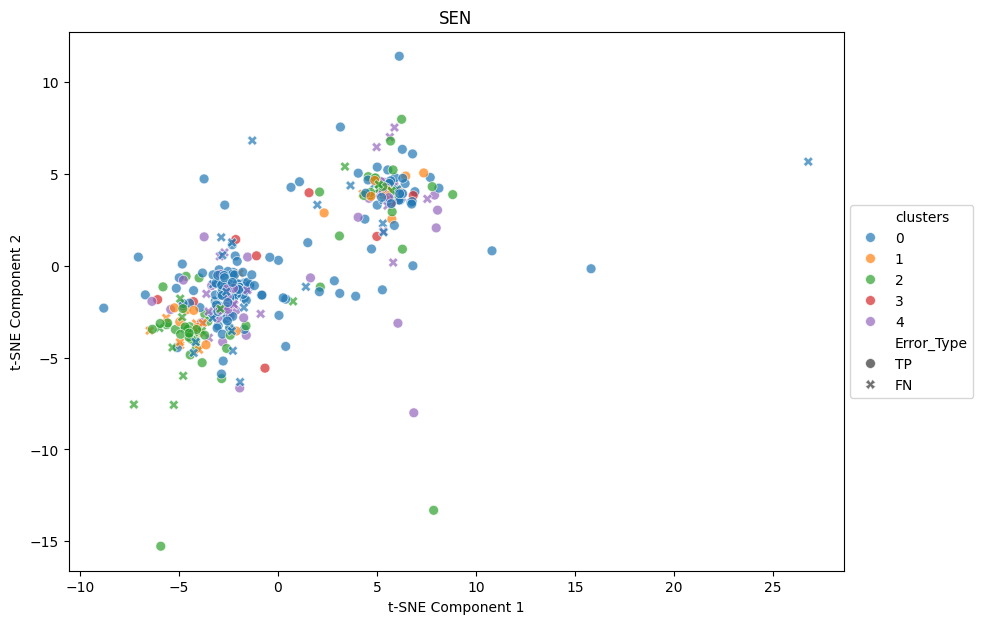

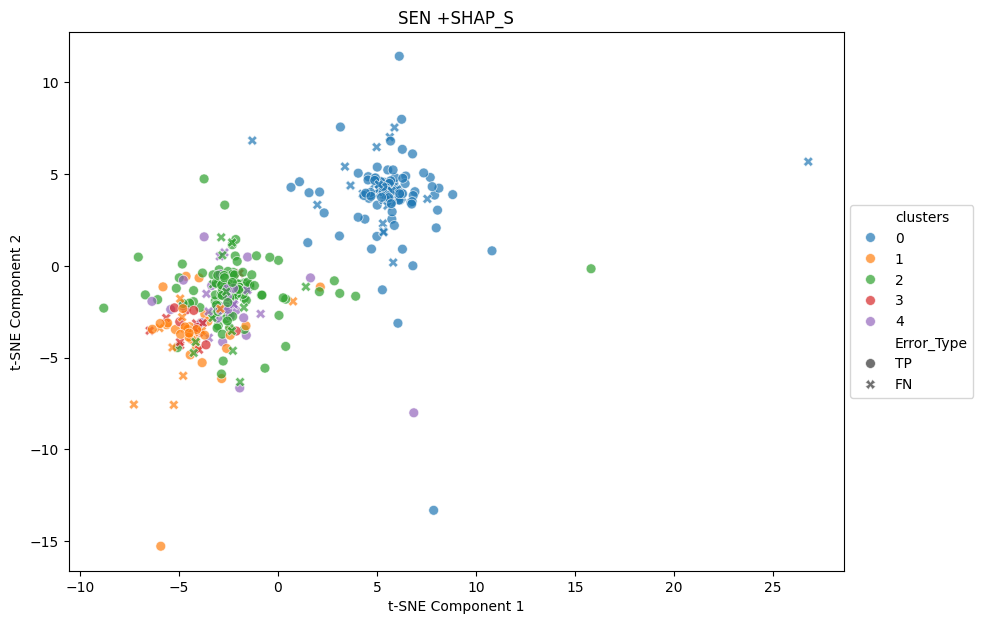

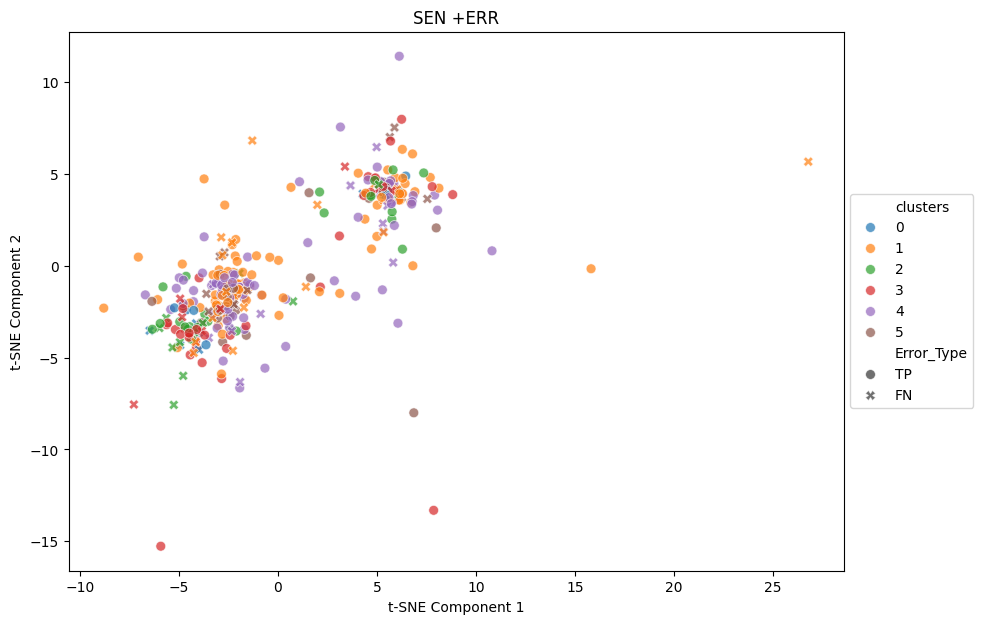

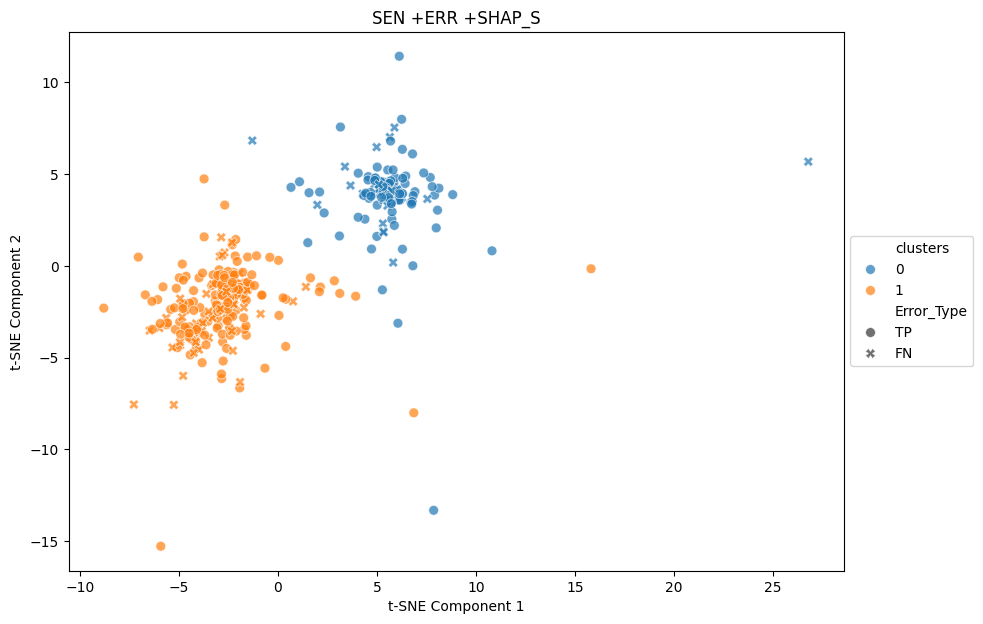

In [37]:
for i in range(0, len(exp_condition)):
  plt.figure(figsize=(10,7))
  tsne_plot_wClusters(results['cond_res'][i], title = re.sub(' +', ' ', results['cond_name'][i]),
                      alpha = 0.7, size = 50,
          tsne_columns = REG_scaled + DUMMY_scaled + SHAP_REG_scaled + SHAP_DUMMY_scaled,
          perplexity = 30, learning_rate = 200, n_iter = 250, fig_prefix='TPFN_Kproto_tSNE_')

# DOWNLOAD FIGURES

In [ ]:
'''for i in range(0, 9):
  print(i)
  files.download('TNFP_Kproto_'+re.sub(' +', '', exp_condition['feature_set_name'][i])+'.png')'''

"for i in range(0, 9):\n  print(i)\n  files.download('TNFP_Kproto_'+re.sub(' +', '', exp_condition['feature_set_name'][i])+'.png')"

In [ ]:
'''for i in range(9, 18):
  print(i)
  files.download('TNFP_Kproto_'+re.sub(' +', '', exp_condition['feature_set_name'][i])+'.png')'''

"for i in range(9, 18):\n  print(i)\n  files.download('TNFP_Kproto_'+re.sub(' +', '', exp_condition['feature_set_name'][i])+'.png')"

In [ ]:
'''for i in range(0, 9):
  print(i)
  files.download('TNFP_Kproto_tSNE_'+re.sub(' +', '', exp_condition['feature_set_name'][i])+'.png')'''

"for i in range(0, 9):\n  print(i)\n  files.download('TNFP_Kproto_tSNE_'+re.sub(' +', '', exp_condition['feature_set_name'][i])+'.png')"

In [ ]:
'''for i in range(9, 18):
  print(i)
  files.download('TNFP_Kproto_tSNE_'+re.sub(' +', '', exp_condition['feature_set_name'][i])+'.png')'''

"for i in range(9, 18):\n  print(i)\n  files.download('TNFP_Kproto_tSNE_'+re.sub(' +', '', exp_condition['feature_set_name'][i])+'.png')"

In [ ]:
'''for i in range(0, 9):
  print(i)
  files.download('TPFN_Kproto_'+re.sub(' +', '', exp_condition['feature_set_name'][i])+'.png')'''

"for i in range(0, 9):\n  print(i)\n  files.download('TPFN_Kproto_'+re.sub(' +', '', exp_condition['feature_set_name'][i])+'.png')"

In [ ]:
'''for i in range(9, 18):
  print(i)
  files.download('TPFN_Kproto_'+re.sub(' +', '', exp_condition['feature_set_name'][i])+'.png')'''

"for i in range(9, 18):\n  print(i)\n  files.download('TPFN_Kproto_'+re.sub(' +', '', exp_condition['feature_set_name'][i])+'.png')"

In [ ]:
'''for i in range(0, 9):
  print(i)
  files.download('TPFN_Kproto_tSNE_'+re.sub(' +', '', exp_condition['feature_set_name'][i])+'.png')'''

"for i in range(0, 9):\n  print(i)\n  files.download('TPFN_Kproto_tSNE_'+re.sub(' +', '', exp_condition['feature_set_name'][i])+'.png')"

In [ ]:
'''for i in range(9, 18):
  print(i)
  files.download('TPFN_Kproto_tSNE_'+re.sub(' +', '', exp_condition['feature_set_name'][i])+'.png')'''

"for i in range(9, 18):\n  print(i)\n  files.download('TPFN_Kproto_tSNE_'+re.sub(' +', '', exp_condition['feature_set_name'][i])+'.png')"